In [100]:
# import all libraries
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.ticker as mtick

# libraries for ARIMA/X
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

#Libraries for Randomforest
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.inspection import (
    permutation_importance,
    PartialDependenceDisplay
)

# Libraries for Regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import r2_score
import statsmodels.formula.api as smf
from scipy.stats.mstats import winsorize
from sklearn.model_selection import TimeSeriesSplit

In [101]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


# Geographical Trends

In [103]:
# read in 10 year interest rate
interest = pd.read_csv("/content/drive/MyDrive/Dat490 Capstone/10-Year Real Interest Rate.csv") # set your path

In [104]:
# read in 30 yr mortgage
morg30 = pd.read_csv("/content/drive/MyDrive/Dat490 Capstone/MORTGAGE30US.csv") # set your path

In [105]:
# read in 15 yr mortgage
morg15 = pd.read_csv("/content/drive/MyDrive/Dat490 Capstone/MORTGAGE15US.csv") # set your path

In [106]:
# read in housing data
housing = pd.read_csv("/content/drive/MyDrive/Dat490 Capstone/Historical_Housing_inventory_by_zipcode_.csv") # set your path


In [107]:
# Check for missing values
housing.isnull().sum()

,0
month_date_yyyymm,0
postal_code,0
zip_name,19704
median_listing_price,1280
median_listing_price_mm,32438
median_listing_price_yy,77795
active_listing_count,0
active_listing_count_mm,39143
active_listing_count_yy,90632
median_days_on_market,5525


In [108]:
# Drop rows with less data
# price_increased_count
# price_increased_count_mm
# price_increased_count_yy

# Check if the columns exist before dropping
columns_to_drop = ['price_increased_count', 'price_increased_count_mm', 'price_increased_count_yy']
existing_columns = housing.columns

columns_to_drop = [col for col in columns_to_drop if col in existing_columns]

# Drop only the existing columns
if columns_to_drop:  # Check if there are any columns to drop
    housing = housing.drop(columns=columns_to_drop)
else:
    print("Columns to drop not found in the DataFrame.")



In [109]:
# Fill missing values with the mean of each *numeric* column
for col in housing.select_dtypes(include=['number']).columns:
    if housing[col].isnull().any():
        housing[col].fillna(housing[col].mean(), inplace=True)

# Verify that there are no more missing values in numeric columns
housing.select_dtypes(include=['number']).isnull().sum()

<ipython-input-109-d6c1fdfe679b>:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





,0
month_date_yyyymm,0
postal_code,0
median_listing_price,0
median_listing_price_mm,0
median_listing_price_yy,0
active_listing_count,0
active_listing_count_mm,0
active_listing_count_yy,0
median_days_on_market,0
median_days_on_market_mm,0


In [ ]:
# Drop rows with any missing values
housing.dropna(inplace=True)

#Check again for missing values
housing.isnull().sum()

housing.describe()

In [ ]:
# Convert 'month_date_yyyymm' to datetime format
housing['month_date_yyyymm'] = pd.to_datetime(housing['month_date_yyyymm'], format='%Y%m')

In [ ]:
# Ensure all numeric columns are correctly typed

# Identify numeric columns
numeric_cols = housing.select_dtypes(include=['number']).columns

# Convert numeric columns to appropriate numeric types
for col in numeric_cols:
    housing[col] = pd.to_numeric(housing[col], errors='coerce')

housing.info()


In [ ]:
# Identify potential outliers using IQR method
for col in numeric_cols:
    Q1 = housing[col].quantile(0.25)
    Q3 = housing[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = housing[(housing[col] < lower_bound) | (housing[col] > upper_bound)]
    if not outliers.empty:
      print(f"Outliers detected in column '{col}':")
outliers[[col]]

In [ ]:
# Outlier treatment: Capping
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)
    return df

for col in numeric_cols:
    Q1 = housing[col].quantile(0.25)
    Q3 = housing[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = housing[(housing[col] < lower_bound) | (housing[col] > upper_bound)]
    if not outliers.empty:
        print(f"Capping outliers in column '{col}'")
        housing = cap_outliers(housing, col)

# Verify outlier treatment
for col in numeric_cols:
    Q1 = housing[col].quantile(0.25)
    Q3 = housing[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = housing[(housing[col] < lower_bound) | (housing[col] > upper_bound)]
    if not outliers.empty:
        print(f"Outliers still detected in column '{col}' after capping:")
outliers[[col]]


In [ ]:
# Check for duplicate rows
duplicate_rows = housing[housing.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")

# Remove duplicate rows
housing.drop_duplicates(inplace=True)

# Verify that duplicates have been removed
print(f"Number of rows after removing duplicates: {len(housing)}")
print(f"Number of duplicate rows after removing duplicates: {len(housing[housing.duplicated()])}")


In [ ]:
# Analyze the quality flag:
print(housing['quality_flag'].value_counts())  # See the distribution of quality flags


In [ ]:
# Change 'month_date_yyyymm' in 'housing' to be 'observation_date'
housing.rename(columns = {'month_date_yyyymm': 'observation_date'}, inplace = True)
housing['observation_date'] = pd.to_datetime(housing['observation_date'])
housing.head()

In [ ]:
# Split 'zip_name' to be 'city' and 'state'
housing[['city', 'state']] = housing['zip_name'].str.split(', ', expand = True)
housing.drop(columns = ['zip_name'], inplace = True)
housing['city'] = housing['city'].str.capitalize()
housing['state'] = housing['state'].str.upper()
cols = list(housing.columns)
cols = cols[:2] + cols[-2:] + cols[2:-2]
housing = housing[cols]
housing.head()

In [ ]:
# Add 'region' column
region_mapping = {
    'AL': 'Southeast',
    'AK': 'West',
    'AZ': 'West',
    'AR': 'South',
    'CA': 'West',
    'CO': 'West',
    'CT': 'Northeast',
    'DE': 'Northeast',
    'FL': 'South',
    'GA': 'South',
    'HI': 'West',
    'ID': 'West',
    'IL': 'Midwest',
    'IN': 'Midwest',
    'IA': 'Midwest',
    'KS': 'Midwest',
    'KY': 'South',
    'LA': 'South',
    'ME': 'Northeast',
    'MD': 'South',
    'MA': 'Northeast',
    'MI': 'Midwest',
    'MN': 'Midwest',
    'MS': 'South',
    'MO': 'Midwest',
    'MT': 'West',
    'NE': 'Midwest',
    'NV': 'West',
    'NH': 'Northeast',
    'NJ': 'Northeast',
    'NM': 'West',
    'NY': 'Northeast',
    'NC': 'South',
    'ND': 'Midwest',
    'OH': 'Midwest',
    'OK': 'South',
    'OR': 'West',
    'PA': 'Northeast',
    'RI': 'Northeast',
    'SC': 'South',
    'SD': 'Midwest',
    'TN': 'South',
    'TX': 'South',
    'UT': 'West',
    'VT': 'Northeast',
    'VA': 'South',
    'WA': 'West',
    'WV': 'South',
    'WI': 'Midwest',
    'WY': 'West'
}
housing.insert(housing.columns.get_loc('state') + 1, 'region', housing['state'].map(region_mapping))
housing.head()

In [ ]:
# Add 'season' column
housing['observation_date'] = pd.to_datetime(housing['observation_date'])
housing.insert(housing.columns.get_loc('observation_date') + 1, 'season', '')
housing.loc[(housing['observation_date'].dt.month >= 3) & (housing['observation_date'].dt.month <= 5), 'season'] = 'spring'
housing.loc[(housing['observation_date'].dt.month >= 6) & (housing['observation_date'].dt.month <= 8), 'season'] = 'summer'
housing.loc[(housing['observation_date'].dt.month >= 9) & (housing['observation_date'].dt.month <= 11), 'season'] = 'fall'
housing.loc[(housing['observation_date'].dt.month == 12) | (housing['observation_date'].dt.month <= 2), 'season'] = 'winter'
housing['season'] = housing['season'].str.capitalize()
housing.head()

In [ ]:
# Merge 'interest', 'morg30', 'morg15', and 'housing'
merge = pd.merge(interest, morg30[['MORTGAGE30US', 'observation_date']], on = 'observation_date')
merge = pd.merge(merge, morg15[['MORTGAGE15US', 'observation_date']], on = 'observation_date')
merge['observation_date'] = pd.to_datetime(merge['observation_date'])
merge = pd.merge(merge, housing, on = 'observation_date')

# MultiIndex
tuples = []
for col in merge.columns:
    if col == 'observation_date':
        tuples.append(('', col))
    elif col in interest.columns and col != 'month_date_yyyymm':
        tuples.append(('interest', col))
    elif col in morg30.columns and col != 'month_date_yyyymm':
        tuples.append(('morg30', col))
    elif col in morg15.columns and col != 'month_date_yyyymm':
        tuples.append(('morg15', col))
    else:
        tuples.append(('housing', col))
merge.columns = pd.MultiIndex.from_tuples(tuples)
merge.head()

Reference: (pandas, 2017)

Regional

In [ ]:
# Distribution of Median Listing Price by Region
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 8))
sns.kdeplot(
    data=merge,
    x=('housing', 'median_listing_price'),
    hue=('housing', 'region'),
    fill=True,
    common_norm=False,
    palette="crest",
    alpha=0.7,
    linewidth=1,
    ax=ax
)
ax.set_title('Distribution of Median Listing Price by Region', fontsize=16, fontweight='bold')
ax.set_xlabel('Median Listing Price', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
regions = merge[('housing', 'region')].dropna().unique()
palette = sns.color_palette("crest", n_colors=len(regions))
handles = [mpatches.Patch(color=color, label=region) for color, region in zip(palette, regions)]
legend = ax.legend(handles=handles, title="Region", loc='center right', bbox_to_anchor=(1.15, 0.5))
sns.despine()
plt.show()

# Print the mean median listing price by region
print(f"Mean of 'median_listing_price' by region:")
print(merge[('housing', 'median_listing_price')].groupby(merge[('housing', 'region')]).mean())

Reference: (McKeever, 2020)

State

In [ ]:
# Median Listing Price by State

locations = merge[('housing', 'state')]
color_data = merge[('housing', 'median_listing_price')]
merge_reset = merge.reset_index()
merge_reset.columns = ['_'.join(col).strip('_') for col in merge_reset.columns.values]
fig = px.choropleth(
       merge_reset,
       locations='housing_state',
       color='housing_median_listing_price',
       locationmode='USA-states',
       scope='usa',
       color_continuous_scale='Viridis',
       title='<b>Median Listing Price by State</b>',
       labels={'housing_median_listing_price': 'Median Price'},
       hover_name='housing_state',
       hover_data={'housing_median_listing_price': True}
   )
fig.update_geos(
       visible=False,
       showcountries=True,
       countrycolor='lightgray'
   )
fig.update_layout(
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
    coloraxis_colorbar=dict(
        title='<b>Median Price</b>',
        x=0.9,
        y=0.5,
        thickness=20
    ),
    title=dict(
        text='<b>Median Listing Price by State</b>',
        x=0.5,
        y=0.95
    )
)
fig.show()


Reference: (plotlygraphs, 2019)

In [ ]:
# Median Listing Price by Postal Code
postal_code_median_price = merge.groupby(('housing', 'postal_code'))[[('housing', 'median_listing_price')]].mean().reset_index()
postal_code_median_price.columns = ['_'.join(col).strip('_') for col in postal_code_median_price.columns.values]
merge_reset = merge.reset_index()
merge_reset.columns = ['_'.join(col).strip('_') for col in merge_reset.columns.values]
postal_code_data = pd.merge(
    postal_code_median_price,
    merge_reset[['housing_postal_code', 'housing_active_listing_count', 'housing_pending_ratio']],
    on='housing_postal_code',
    how='left'
)
postal_code_data = postal_code_data.drop_duplicates(subset=['housing_postal_code'])
fig = px.scatter(
    postal_code_data,
    x='housing_active_listing_count',
    y='housing_median_listing_price',
    size='housing_pending_ratio',
    color='housing_median_listing_price',
    hover_name='housing_postal_code',
    title='<b>Median Listing Price by Postal Code</b>',
    labels={'housing_active_listing_count': 'Active Listings',
            'housing_median_listing_price': 'Median Listing Price',
            'housing_pending_ratio': 'Pending Ratio'},
    color_continuous_scale='Viridis',
)
fig.update_layout(
    xaxis_title='Active Listings',
    yaxis_title='Median Listing Price',
)
fig.show()

Reference: (plotlygraphs, 2019)

# Factors Affecting U.S. Housing Prices & Machine Learning Model Comparison

In [ ]:
# read in merged time series data
ts_df= pd.read_csv("/content/drive/MyDrive/Dat490 Capstone/ts_merge.csv") # set your path

In [ ]:
# dataframe before setting 'date' to datetime format and then setting as index
ts_df.head()

In [ ]:
################################# THIS DATA FRAME --> new_ts_df <---- IS INDEXED BY THE 'date' COLUMN AND IS READY TO BE USED FOR TIMES SERIES ANALYSIS############################

# : Create a copy of the original DataFrame
new_ts_df = ts_df.copy()

#  Convert the 'date' column to datetime format
new_ts_df['date'] = pd.to_datetime(new_ts_df['date'], format='%m/%d/%Y')

#  Set 'date' column as the index
new_ts_df.set_index('date', inplace=True)



### Taking a look at median listing price over time

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(new_ts_df.index, ts_df['median_listing_price'], label='Median Listing Price', color='green')
plt.title('Median Listing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Median Listing Price')
plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.show()


### **Naive Bayes Baseline Model**  -- This acts as a benchmark to measure our model's performance against.

In [ ]:
# Create a copy of new_ts_df to baseline
baseline = new_ts_df.copy()

In [ ]:
# Define number of months to forecast
forecast_horizon = 24

# Get the last date and last observed value
last_date = pd.to_datetime(baseline.index[-1])  # Ensure last_date is in datetime format
last_value = baseline["median_listing_price"].iloc[-1]

# Create future date range (monthly)
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_horizon, freq='MS')

# Create the forecast DataFrame
naive_forecast = pd.DataFrame({
    "median_listing_price": [last_value] * forecast_horizon
}, index=future_dates)


In [ ]:

# Plot the actual values
plt.figure(figsize=(14, 6))
plt.plot(baseline.index, baseline['median_listing_price'], label="Actual", color="blue")

# Plot the Naive Forecast values
plt.plot(naive_forecast.index, naive_forecast['median_listing_price'], label="Naive Forecast", color="red", linestyle="--")

# Adding title and labels
plt.title("Naive Bayes Baseline Model - 2 Year Forecast of Median Listing Price", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Median Listing Price", fontsize=12)

# Adding a legend to differentiate the two lines
plt.legend()

# Display grid for better readability
#plt.grid(True)

# Adjust layout to avoid overlap of labels and titles
plt.tight_layout()

# Show the plot
plt.show()



(Analytics Vidhya, 2017)

In [ ]:
# Set the number of test periods
test_periods = 24

# Actual values from the last 12 months of data
actual_values = baseline["median_listing_price"].iloc[-test_periods:]

# Naive predictions — repeat the value before the test period
last_train_value = baseline["median_listing_price"].iloc[-test_periods - 1]
predicted_values = pd.Series([last_train_value] * test_periods, index=actual_values.index)


In [ ]:
def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_value = np.mean(np.abs(y_true - y_pred) / denominator) * 100
    return smape_value

baseline_smape_value = smape(actual_values, predicted_values)

print(f'SMAPE for Naive Baseline: {baseline_smape_value:.2f}%')


SMAPE for Baseline is 2.39% <--- We will try to build models that will out perform this.

### ARIMA Univariate Model- 2 Year Forecast using only historcial median listing price

In [ ]:
subset_df = baseline[['median_listing_price']]

### Check if data is stationary

In [ ]:
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] > 0.05:
        print("The data is not stationary.")
    else:
        print("The data is stationary.")

# Perform the ADF test
adf_test(subset_df["median_listing_price"])

### Apply Differencing

In [ ]:
# First order differencing
data_diff = subset_df.diff().dropna()

# Re-run ADF test after differencing
adf_test(data_diff["median_listing_price"])

# Plot the differenced series
plt.figure(figsize=(14, 6))
plt.plot(data_diff, marker='o', linestyle='-')
plt.title("median_listing_price")
plt.xlabel("Year")
plt.ylabel("Differenced median_listing_price")

#plt.grid()
plt.show()

     (Skforecast, 2024)

### Apply seasonal differencing

In [ ]:
# Seasonal differencing with a lag of 12 months
seasonal_diff = subset_df["median_listing_price"].diff(12).dropna()

# ADF test after seasonal differencing
adf_test(seasonal_diff)

# Plot the result
plt.figure(figsize=(14, 6))
plt.plot(seasonal_diff, marker='o', linestyle='-')
plt.title("Seasonally Differenced (Lag=12): median_listing_price")
plt.xlabel("Date")
plt.ylabel("12-Month Differenced median_listing_price")
#plt.grid()
plt.show()

### Differencing and seasonaly differencing didn't work. We wil apply a log transformation to make data stationary

In [ ]:
# Apply log transform to reduce variance (if not already done)
log_data = np.log(subset_df["median_listing_price"])
log_data_diff = log_data.diff().diff(12).dropna()

# ADF test
adf_test(log_data_diff)

# Plot the transformed series
plt.figure(figsize=(14, 6))
plt.plot(log_data_diff, marker='o', linestyle='-')
plt.title("Log + 1st + Seasonal Differenced: median_listing_price")
plt.xlabel("Date")
plt.ylabel("Log Differenced median_listing_price")
#plt.grid()
plt.show()

In [ ]:
# Resample to ensure consistent monthly frequency
subset_df = subset_df.resample('MS').mean()  # 'MS' = Month Start

### Check Autocorrelation and Partial Autocorrelation, this will help with determining the hyper pararmeter values for p and q.

In [ ]:

# Plot ACF and PACF to decide on p and q
plt.figure(figsize=(12,6))

# ACF plot (helps to determine q)
plt.subplot(121)
plot_acf(subset_df['median_listing_price'], lags=30, ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')

# PACF plot (helps to determine p)
plt.subplot(122)
plot_pacf(subset_df['median_listing_price'], lags=30, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()



## Model Validation and Forecasting Strategy

Before using the ARIMA and or SARIMA models to forecast future values, we first validate its performance by predicting a test set of **already known values**. This step ensures the model is capable of generalizing well and accurately capturing trends in the data.

### Why this step is important:
- We **train the model on historical data** (train set).
- Then, we will **forecasted values for the test period** (e.g., the last 12 months of known data).
- The predicted values are then  **compared to actual values** to evaluate model accuracy using metrics like **SMAPE** (Symmetric Mean Absolute Percentage Error) and visual plots.

Once the model demonstrates strong performance on known data, we can confidently **retrain it on the full dataset** (train + test) and proceed to make forecasts for the **future (unseen) periods**.

This two-step approach ensures reliable forecasting and reduces the risk of overfitting or poor generalization.


In [ ]:
# split into train and test sets
train = subset_df.iloc[:-12]
test = subset_df.iloc[-12:]

In [ ]:
# Define the ARIMA model with chosen parameters (p=1, d=0, q=1)
model = ARIMA(subset_df['median_listing_price'], order=(1, 0, 1))  # Change parameters if needed

# Fit the model
model_fit = model.fit()

# Display the model summary
print(model_fit.summary())


In [ ]:
# Forecast the next 12 months
forecast = model_fit.forecast(steps=12)
forecast.index = test.index

(Skforecast, 2024)

In [ ]:
def evaluate_forecast(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # SMAPE calculation
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_val = np.mean(np.abs(y_true - y_pred) / denominator) * 100

    # MAE and RMSE
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return smape_val, mae, rmse

# Example usage
arima_smape, arima_mae, arima_rmse = evaluate_forecast(test['median_listing_price'], forecast)

print(f"SMAPE for ARIMA Model: {arima_smape:.2f}%")
print(f"Accuracy (100 - SMAPE): {100 - arima_smape:.2f}%")
print(f"MAE for ARIMA Model: {arima_mae:.2f}")
print(f"RMSE for ARIMA Model: {arima_rmse:.2f}")



SMAPE (Symmetric Mean Absolute Percentage Error): 2.14%
 A very low error rate, which means our forecast is closely tracking the actual values.

Accuracy (100 - SMAPE): 97.86%
 A simple way to express how well the model is performing.

MAE (Mean Absolute Error): 9000.58
 On average, our forecast is about $9,000 away from the true value.

RMSE (Root Mean Squared Error): 11872.85
Similar to MAE, but it penalizes larger errors more. The higher RMSE compared to MAE suggests there are a few forecasts with higher deviation.

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['median_listing_price'], label='Train')
plt.plot(test.index, test['median_listing_price'], label='Test', color='orange')
plt.plot(forecast.index, forecast, label='ARIMA Forecast', color='green', linestyle='--')
plt.legend()
plt.title('ARIMA Univariate Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Median Listing Price')
#plt.grid(True)
plt.tight_layout()
plt.show()


We are ready to start our forecasting, but since we can't check performance of our forecasted model, because we don't have data to verify against, we will first do Backtesting.Backtesting is the process of testing a predictive model or strategy on historical data to evaluate its performance before applying it to future data. It involves using past data to simulate how well the model would have performed in real-world scenarios, allowing us to assess its predictive accuracy.
 - Backtesting helps determine if the model can make reliable predictions by evaluating it on known data before forecasting future values.
 -     For our model, we trained it on historical data and used a subset of the data as a "test set" to compare the model's predictions against actual values. This provides an objective measure of the model's accuracy, which in our case is done using metrics like SMAPE.

By performing backtesting, we can confidently validate the model's ability to forecast future data, ensuring it is robust and accurate for practical use.

### We will backtest for 12 months first, then 24 months and compare

In [ ]:

# Split the data into training and testing (last 12 months as test)
train = subset_df[:-12]
test = subset_df[-12:]

# Fit ARIMA model on the training data
model_bt = ARIMA(train['median_listing_price'], order=(1, 0, 1))  # Use the same order as before
model_bt_fit = model_bt.fit()

# Forecast the next 12 months (same length as test set)
forecast_bt = model_bt_fit.forecast(steps=12)

# Define evaluation function
def evaluate_forecast(y_true, y_pred):
    """
    Calculate SMAPE, MAE, RMSE, and accuracy for forecast evaluation.
    """
    # Convert to numpy arrays
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Calculate SMAPE
    smape = np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2)) * 100

    # Calculate MAE
    mae = mean_absolute_error(y_true, y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Calculate accuracy based on SMAPE
    accuracy = 100 - smape

    return smape, mae, rmse, accuracy

# STEP 5: Evaluate performance using the new function
bt_smape, bt_mae, bt_rmse, bt_accuracy = evaluate_forecast(test['median_listing_price'], forecast_bt)

print(f'SMAPE on 12-month backtest: {bt_smape:.2f}%')
print(f'MAE on 12-month backtest: {bt_mae:.2f}')
print(f'RMSE on 12-month backtest: {bt_rmse:.2f}')
print(f'Accuracy on 12-month backtest: {bt_accuracy:.2f}%')

# STEP 6 (Optional): Plot the actual vs forecasted values
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['median_listing_price'], label='Training Data')
plt.plot(test.index, test['median_listing_price'], label='Actual (Test)', color='black')
plt.plot(test.index, forecast_bt, label='Forecasted', color='orange', linestyle='--')
plt.title("Backtesting UnivariateForecast vs Actuals (12 months)")
plt.xlabel("Date")
plt.ylabel("Median Listing Price")
plt.legend()
#plt.grid(True)
plt.show()


(Skforecast, 2024)

In [ ]:
# Split the data into training and testing (last 24 months as test)
train = subset_df[:-24]  # Training data: everything before the last 24 months
test = subset_df[-24:]   # Test data: the last 24 months

#  Fit ARIMA model on the training data
model_bt = ARIMA(train['median_listing_price'], order=(1, 0, 1))  # Use the same order as before
model_bt_fit = model_bt.fit()

# Forecast the next 24 months (same length as test set)
forecast_bt = model_bt_fit.forecast(steps=24)

#Define evaluation function
def evaluate_forecast(y_true, y_pred):
    """
    Calculate SMAPE, MAE, RMSE, and accuracy for forecast evaluation.
    """
    # Convert to numpy arrays
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Calculate SMAPE
    smape = np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2)) * 100

    # Calculate MAE
    mae = mean_absolute_error(y_true, y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Calculate accuracy based on SMAPE
    accuracy = 100 - smape

    return smape, mae, rmse, accuracy
# Evaluate performance using the new function
bt_smape, bt_mae, bt_rmse, bt_accuracy = evaluate_forecast(test['median_listing_price'], forecast_bt)

print(f'SMAPE on 24-month backtest: {bt_smape:.2f}%')
print(f'MAE on 24-month backtest: {bt_mae:.2f}')
print(f'RMSE on 24-month backtest: {bt_rmse:.2f}')
print(f'Accuracy on 24-month backtest: {bt_accuracy:.2f}%')

#  Plot the actual vs forecasted values


plt.figure(figsize=(14, 6))
plt.plot(train.index, train['median_listing_price'], label='Training Data')
plt.plot(test.index, test['median_listing_price'], label='Actual (Test)', color='black')
plt.plot(test.index, forecast_bt, label='Forecasted', color='orange', linestyle='--')
plt.title("Backtesting Univariate Forecast vs Actuals (24 months)")
plt.xlabel("Date")
plt.ylabel("Median Listing Price")
plt.legend()
#plt.grid(True)
plt.show()


(Skforecast, 2024)

97.89 % accuracy with the 12month backtest vs. 97.46% for 24 month. There is just a small variation. We will attempt to forecast for 2 years.

In [ ]:
# Fit the ARIMA model on the entire dataset
model_full = ARIMA(subset_df['median_listing_price'], order=(1, 0, 1))
model_fit_full = model_full.fit()

In [ ]:
# Forecast 24 months into the future
forecast_steps = 24
forecast = model_fit_full.forecast(steps=forecast_steps)

# Create future date index
last_date = subset_df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')

# Build forecast DataFrame
forecast_df = pd.DataFrame({'forecast': forecast}, index=future_dates)


In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(subset_df.index, subset_df['median_listing_price'], label='Historical')
plt.plot(forecast_df.index, forecast_df['forecast'], label='2-Year Forecast', color='orange', linestyle='--')
plt.title("ARIMA Univariate 2-Year Forecast of Median Listing Price")
plt.xlabel("Date")
plt.ylabel("Median Listing Price")
#plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


The ARIMA model's forecast is flat, indicating that it's not picking up the trends in seasonality. We will now try SARIMA and see if we get better results.

In [ ]:
# Define the evaluate_forecast function (same as before)
def evaluate_forecast(y_true, y_pred):
    """
    Calculate SMAPE, MAE, RMSE, and accuracy for forecast evaluation.
    """
    # Convert to numpy arrays
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Calculate SMAPE
    smape = np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2)) * 100

    # Calculate MAE
    mae = mean_absolute_error(y_true, y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Calculate accuracy based on SMAPE
    accuracy = 100 - smape

    return smape, mae, rmse, accuracy

# Fit a SARIMA model on the training data
model_sarima = SARIMAX(train['median_listing_price'], order=(1, 0, 1), seasonal_order=(0, 1, 1, 12))  # Add seasonal components
model_sarima_fit = model_sarima.fit()

# Forecast the next 24 months
forecast_sarima = model_sarima_fit.forecast(steps=24)

# Evaluate performance using the new function
sarima_smape, sarima_mae, sarima_rmse, sarima_accuracy = evaluate_forecast(test['median_listing_price'], forecast_sarima)

# Print the metrics
print(f'SMAPE on 24-month SARIMA backtest: {sarima_smape:.2f}%')
print(f'MAE on 24-month SARIMA backtest: {sarima_mae:.2f}')
print(f'RMSE on 24-month SARIMA backtest: {sarima_rmse:.2f}')
print(f'Accuracy on 24-month SARIMA backtest: {sarima_accuracy:.2f}%')

# Plot the actual vs forecasted values
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['median_listing_price'], label='Training Data')
plt.plot(test.index, test['median_listing_price'], label='Actual (Test)', color='black')
plt.plot(test.index, forecast_sarima, label='Forecasted', color='orange', linestyle='--')
plt.title("SARIMA Univariate Forecast vs Actuals (24 months)")
plt.xlabel("Date")
plt.ylabel("Median Listing Price")
plt.legend()
#plt.grid(True)
plt.show()


(Skforecast, 2024)

### Using the SARIMA model, we are now picking up the seasonality and are achieving an accuracy of 97.35%.

### Why SARIMA (0,1,1,12) Was Chosen

After testing SARIMA with various seasonal orders, setting the seasonal order to `(0, 1, 1, 12)` produced a model that performed nearly as well as ARIMA based on SMAPE, while also capturing the expected seasonal fluctuations in the data. The flat forecast from ARIMA missed these patterns.

By removing the seasonal autoregressive component (`P=0`), the model was simplified and less prone to overfitting. The seasonal moving average (`Q=1`) combined with seasonal differencing (`D=1`) was sufficient to model the repeating annual patterns.

This SARIMA configuration strikes a good balance between accuracy and interpretability for seasonal data.


### Now We will use the SARIMA Model to forecast 2 years

In [ ]:

# Fit the model on the entire dataset
model_final = SARIMAX(
    subset_df['median_listing_price'],
    order=(1, 0, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_final_fit = model_final.fit()


(Towards Data Science, 2024)

In [ ]:
# Forecast the next 24 months (2 years)
forecast_2yr = model_final_fit.get_forecast(steps=24)

# Extract predicted values and confidence intervals
forecast_values = forecast_2yr.predicted_mean
conf_int = forecast_2yr.conf_int()


In [ ]:
# Create forecast index
forecast_index = pd.date_range(start=subset_df.index[-1] + pd.DateOffset(months=1), periods=24, freq='MS')

# Plot the forecast
plt.figure(figsize=(14, 6))
plt.plot(subset_df.index, subset_df['median_listing_price'], label='Historical Data')
plt.plot(forecast_index, forecast_values, label='2-Year Forecast', color='orange')
plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='orange', alpha=0.2)
plt.title("2-Year SARIMA Univariate Model Forecast")
plt.xlabel("Date")
plt.ylabel("Median Listing Price")
plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.show()


### 2-Year Forecast with SARIMA

Using the final SARIMA model (order=(1, 0, 1), seasonal_order=(0, 1, 1, 12)), we forecasted 24 months into the future. This model captures the annual seasonality patterns while maintaining low forecast error, making it suitable for forward-looking predictions. The forecast includes a confidence interval to reflect uncertainty.


### Time for feature selection and adding our exogenous features that we will use to build our multivariate models.



In [ ]:
sa = new_ts_df.copy()

In [ ]:
sa.head()

### Begin feauture selection, first correlation heatmap to check feature correlation with target variable.

In [ ]:
# Step 1: Calculate the correlation matrix
correlation_matrix = sa.corr()

# Step 2: Plot the heatmap
plt.figure(figsize=(14, 10))  # Set the size of the figure
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Title and labels
plt.title("Correlation Heatmap of Features and Target", fontsize=16)
plt.show()


### Now calculate Variable Inflation Factor ( VIF ) to check levels of multicollinearity between features.
 - VIF = 1: No correlation between the predictor and other variables (perfectly uncorrelated).

 - 1 < VIF < 5: Moderate correlation, but typically acceptable. Variables with VIF values in this range generally don't need any action.

 - 5 ≤ VIF < 10: High correlation. This could indicate problematic multicollinearity, which may require addressing, by removing.

In [ ]:
## TESTING ALL THE FEATURES TOGETHER

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define the features to test (excluding 'date' and 'median_listing_price' which are not used for VIF)
selected_features = [
    'interest_rate',
    'mortgage30',
    'mortgage15',
    'gdp',
    'active_listing_count',
    'median_days_on_market',
    'new_listing_count',
    'price_increased_count',
    'price_reduced_count',
    'pending_listing_count',
    'median_listing_price_per_square_foot',
    'median_square_feet',
    'total_listing_count',
    'pending_ratio'
]

# Assuming 'arimax_df' is already your time series DataFrame with 'date' set as index

# Step 1: Select only the relevant features (excluding 'date' and 'median_listing_price')
X = sa[selected_features]

# Step 2: Add constant for intercept term in VIF calculation (important for regression models)
X_const = add_constant(X)

# Step 3: Calculate VIF for each feature
vif_df = pd.DataFrame()
vif_df['Feature'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X_const.values, i + 1) for i in range(X.shape[1])]

# Step 4: Display the VIF values
print(vif_df)


In [ ]:
## COMMENT OUT AND DO PROCESS OF ELIMINATION

selected_features = [
    'interest_rate',
   # 'mortgage30',
    #'mortgage15',
   #'gdp',
   # 'active_listing_count',
    'median_days_on_market',
    'new_listing_count',
    'price_increased_count',
    'price_reduced_count',
    #'pending_listing_count',
   # 'median_listing_price_per_square_foot',
    'median_square_feet',
   # 'total_listing_count',
    #'pending_ratio'
]

# Assuming 'arimax_df' is already your time series DataFrame with 'date' set as index

# Step 1: Select only the relevant features (excluding 'date' and 'median_listing_price')
X = sa[selected_features]

# Step 2: Add constant for intercept term in VIF calculation (important for regression models)
X_const = add_constant(X)

# Step 3: Calculate VIF for each feature
vif_df = pd.DataFrame()
vif_df['Feature'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X_const.values, i + 1) for i in range(X.shape[1])]

# Step 4: Display the VIF values
print(vif_df)

In [ ]:
# THIS DATAFRAME HAS THE NARROWED DOWN FEATURES WE ARE USING

# Define the selected features
selected_features = [
    'interest_rate',
    'median_days_on_market',
    'new_listing_count',
    'price_increased_count',
    'price_reduced_count',
    'median_square_feet',
    'median_listing_price'
]

# Create a subset of the original DataFrame with only the selected features
sar_mod = new_ts_df[selected_features].copy()



### Check corrlation between our selected features. We don't want features that highly correlated.

In [ ]:
# Plot the correlation matrix for our exogenous features
correlation_matrix = sar_mod.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Selected Features")
plt.show()


In [ ]:
sar_mod.head()

### SARIMAX Multivariate

In [ ]:

# Split the data into training and testing (last 24 months as test set)
train = sar_mod[:-24]  # Training data: everything before the last 24 months
test = sar_mod[-24:]   # Test data: the last 24 months

# Define the endogenous (target) and exogenous (predictors) variables
endog_train = train['median_listing_price']  # Target variable for training
exog_train = train.drop(columns=['median_listing_price'])  # Exogenous variables for training

endog_test = test['median_listing_price']    # Target variable for testing
exog_test = test.drop(columns=['median_listing_price'])  # Exogenous variables for testing

# Fit the SARIMAX model
sarimax_model = SARIMAX(endog_train, exog=exog_train, order=(1, 0, 1), seasonal_order=(0, 1, 1, 12))
sarimax_model_fit = sarimax_model.fit(maxiter=500)  # Increase maxiter if convergence issues arise

# Print the summary of the model
print(sarimax_model_fit.summary())

# Forecast the next 24 months using the fitted model
forecast_sarima = sarimax_model_fit.forecast(steps=24, exog=exog_test)

# Define the evaluation function to calculate SMAPE, MAE, RMSE, and accuracy
def evaluate_forecast(y_true, y_pred):
    """
    Calculate SMAPE, MAE, RMSE, and accuracy for forecast evaluation.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Calculate SMAPE
    smape = np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2)) * 100

    # Calculate MAE
    mae = mean_absolute_error(y_true, y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Calculate accuracy based on SMAPE
    accuracy = 100 - smape

    return smape, mae, rmse, accuracy

# Evaluate performance using the defined function
sarima_smape, sarima_mae, sarima_rmse, sarima_accuracy = evaluate_forecast(endog_test, forecast_sarima)

# Print the evaluation metrics
print(f'SMAPE on 24-month SARIMAX forecast: {sarima_smape:.2f}%')
print(f'MAE on 24-month SARIMAX forecast: {sarima_mae:.2f}')
print(f'RMSE on 24-month SARIMAX forecast: {sarima_rmse:.2f}')
print(f'Accuracy on 24-month SARIMAX forecast: {sarima_accuracy:.2f}%')

# Plot the actual vs forecasted values
plt.figure(figsize=(14, 6))
plt.plot(train.index, endog_train, label='Training Data')
plt.plot(test.index, endog_test, label='Actual (Test)', color='black')
plt.plot(test.index, forecast_sarima, label='Forecasted', color='orange', linestyle='--')
plt.title("SARIMAX Multivariate Forecast vs Actuals (24 months)")
plt.xlabel("Date")
plt.ylabel("Median Listing Price")
# Customize tick marks for better visibility
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a grid for better readability
#plt.grid(False, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Add a legend with adjusted font size
plt.legend(fontsize=12)

# Tight layout to avoid label cut-off
plt.tight_layout()

# Show the plot
plt.show()




### SARIMAX Multivariate results - 98.15% accuracy using the exogenous features. This is an increase from SARIMA, ARIMA, & Baseline where only the historcal median listing price was used to forecast.



### **Inferential Stastics**

In [ ]:
# T-Statisics and P-Values for  Coefficents
# After fitting the model
print(sarimax_model_fit.summary())

# Extract p-values for each coefficient
p_values = sarimax_model_fit.pvalues
print("\nP-values for each coefficient:")
print(p_values)


In [ ]:
# Extract the confidence intervals
conf_int = sarimax_model_fit.conf_int()
print("\nConfidence intervals for each coefficient:")
print(conf_int)


### We will now use SARIMAX to forecast the next 2 years.

In [ ]:
sar_mod

In [ ]:
# Combine the train and test sets to create the full dataset
full_data = sar_mod  # This is your entire dataset

# Define the endogenous (target) and exogenous (predictors) variables
endog_full = full_data['median_listing_price']  # Target variable
exog_full = full_data.drop(columns=['median_listing_price'])  # Exogenous variables

# Fit the SARIMAX model on the entire dataset
sarimax_model_full = SARIMAX(endog_full, exog=exog_full, order=(1, 0, 1), seasonal_order=(0, 1, 1, 12))
sarimax_model_full_fit = sarimax_model_full.fit(maxiter=500)  # Increase maxiter if convergence issues arise

# Print the summary of the model
print(sarimax_model_full_fit.summary())

In [ ]:

# Creating a new 'exog_future' DataFrame with the same structure as 'sar_mod' but for future dates
future_dates = pd.date_range(start=full_data.index[-1] + pd.DateOffset(months=1), periods=24, freq='MS')

exog_future = sar_mod.drop(columns=['median_listing_price']).iloc[-24:].copy()  # Example of using the last available features for future forecasting
exog_future.index = future_dates  # Ensure the future dates align

# Forecast the next 24 months using the fitted SARIMAX model
forecast_sarima_2years = sarimax_model_full_fit.get_forecast(
    steps=24,
    exog=exog_future
)

# Extract the forecasted values
forecast_values = forecast_sarima_2years.predicted_mean

# Create a DataFrame for the forecasted values
forecast_df = pd.DataFrame({'forecast': forecast_values}, index=future_dates)

In [ ]:
plt.figure(figsize=(14, 6))

# Plot historical data
plt.plot(full_data.index, full_data['median_listing_price'], label='Historical Data', color='dodgerblue', linewidth=2)

# Plot forecasted data (2-year forecast)
plt.plot(forecast_df.index, forecast_df['forecast'], label='2-Year Forecast', color='darkorange', linestyle='--', linewidth=2)

# Title with larger font size
plt.title("2-Year SARIMAX Forecast of Median Listing Price", fontsize=16, fontweight='bold')

# Labels for axes with font size adjustments
plt.xlabel("Date", fontsize=14)
plt.ylabel("Median Listing Price ($)", fontsize=14)

# Customize tick marks for better visibility
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a grid for better readability
#plt.grid(False, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Add a legend with adjusted font size
plt.legend(fontsize=12)

# Tight layout to avoid label cut-off
plt.tight_layout()

# Show the plot
plt.show()


# Random Forest

## EDA

In [ ]:
# Dataset
X = sar_mod.drop('median_listing_price', axis=1)
y = sar_mod['median_listing_price']

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(sar_mod.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# VIF
X_const = add_constant(X)
vif_df = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X_const.values, i + 1) for i in range(X.shape[1])]
})
print(vif_df)

In [ ]:
# Feature Importance (RF)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

feature_importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(10), y='Feature', x='Importance', palette='viridis')
plt.title('Top Feature Importances')
plt.tight_layout()
plt.show()

In [ ]:
# Partial Dependence Plot

!pip install scikit-learn --upgrade
from sklearn.inspection import partial_dependence
from sklearn.inspection import PartialDependenceDisplay

# Get top features from feat_imp_df created in previous cell (ipython-input-52-...)
top_features = feat_imp_df.head(10)  # Or however many you want to plot

features_to_plot = top_features['Feature'].tolist()
display = PartialDependenceDisplay.from_estimator(
    rf_model, X_train, features_to_plot, kind="both"
)
display.figure_.suptitle("Partial Dependence Plots for Top Features", fontsize=16)
display.figure_.set_size_inches(12, 8)  # Adjust figure size
plt.tight_layout()
plt.show()

## Inferential Statistics

In [ ]:
# Permutation importance
perm_result = permutation_importance(rf_model, X_test, y_test, n_repeats=30, random_state=42)
perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': perm_result.importances_mean,
    'CI_Lower': perm_result.importances_mean - 1.96 * perm_result.importances_std,
    'CI_Upper': perm_result.importances_mean + 1.96 * perm_result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)
print("Permutation Importance with Confidence Intervals:")
print(perm_df)


Permutation Importance with Confidence Intervals:
                 Feature  Importance_Mean  CI_Lower  CI_Upper
3  price_increased_count         0.420023  0.182943  0.657103
5     median_square_feet         0.402093  0.183317  0.620868
0          interest_rate         0.172653  0.104948  0.240358
1  median_days_on_market         0.075877  0.006994  0.144761
4    price_reduced_count         0.039112 -0.005250  0.083474
2      new_listing_count         0.008410  0.001198  0.015621


In [ ]:
# Bootstrap Resampling

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0.0
    return np.mean(diff) * 100

def bootstrap_metrics(y_true, y_pred, n_bootstraps=1000):
    smape_vals, mae_vals, rmse_vals = [], [], []
    n = len(y_true)
    for _ in range(n_bootstraps):
        idx = np.random.choice(range(n), size=n, replace=True)
        smape_vals.append(smape(y_true[idx], y_pred[idx]))
        mae_vals.append(mean_absolute_error(y_true[idx], y_pred[idx]))
        rmse_vals.append(np.sqrt(mean_squared_error(y_true[idx], y_pred[idx])))
    return {
        'SMAPE_CI': (np.percentile(smape_vals, 2.5), np.percentile(smape_vals, 97.5)),
        'MAE_CI': (np.percentile(mae_vals, 2.5), np.percentile(mae_vals, 97.5)),
        'RMSE_CI': (np.percentile(rmse_vals, 2.5), np.percentile(rmse_vals, 97.5))
    }

ci_results = bootstrap_metrics(y_test.values, rf_model.predict(X_test))
print("\nBootstrap 95% Confidence Intervals:")
for metric, (low, high) in ci_results.items():
    print(f"{metric}: [{low:.2f}, {high:.2f}]")



Bootstrap 95% Confidence Intervals:
SMAPE_CI: [1.75, 5.03]
MAE_CI: [5895.95, 16240.93]
RMSE_CI: [7980.28, 22865.34]


In [ ]:
# Copy dataset
ols_df = sar_mod.copy()

# Add squared terms
for feature in X.columns:
    ols_df[f"{feature}_sq"] = ols_df[feature] ** 2

# Interaction terms (optional - using top 3 features for clarity)
interaction_terms = ' + '.join([
    f'{X.columns[0]}:{X.columns[1]}',
    f'{X.columns[1]}:{X.columns[2]}'
])

# Construct formula
linear_terms = ' + '.join(X.columns)
squared_terms = ' + '.join([f"{f}_sq" for f in X.columns])
formula = f"median_listing_price ~ {linear_terms} + {squared_terms} + {interaction_terms}"

# Fit model
ols_model = smf.ols(formula=formula, data=ols_df).fit()

# Print with custom title
print(f"\n{'='*30}")
print("OLS Regression on Random Forest Features")
print(f"{'='*30}")
print(ols_model.summary())



OLS Regression on Random Forest Features
                             OLS Regression Results                             
Dep. Variable:     median_listing_price   R-squared:                       0.947
Model:                              OLS   Adj. R-squared:                  0.939
Method:                   Least Squares   F-statistic:                     124.0
Date:                  Fri, 25 Apr 2025   Prob (F-statistic):           6.41e-52
Time:                          22:38:28   Log-Likelihood:                -1156.1
No. Observations:                   105   AIC:                             2340.
Df Residuals:                        91   BIC:                             2377.
Df Model:                            13                                         
Covariance Type:              nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

## Modeling

In [ ]:
# Univariate Random Forest
results_uni = []
for feature in X.columns:
    X_uni = X[[feature]]
    X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(X_uni, y, test_size=0.2, shuffle=False)
    rf_uni = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_uni.fit(X_train_u, y_train_u)
    y_pred_u = rf_uni.predict(X_test_u)
    smape_val = smape(y_test_u, y_pred_u)
    results_uni.append({
        'Feature': feature,
        'SMAPE': smape_val,
        'MAE': mean_absolute_error(y_test_u, y_pred_u),
        'RMSE': np.sqrt(mean_squared_error(y_test_u, y_pred_u)),
        'ACC (%)': 100 - smape_val
    })
uni_df = pd.DataFrame(results_uni).sort_values(by='ACC (%)', ascending=False)
print(uni_df)

                 Feature      SMAPE            MAE           RMSE    ACC (%)
0          interest_rate   2.604417   10986.575714   13647.150223  97.395583
3  price_increased_count   4.142083   17152.993810   23003.245804  95.857917
5     median_square_feet  15.186593   57738.437540   72912.648779  84.813407
2      new_listing_count  17.629200   67544.471429   77667.835435  82.370800
1  median_days_on_market  21.173768   78285.675175   87245.709284  78.826232
4    price_reduced_count  28.025933  102295.134762  111640.883618  71.974067


In [ ]:
# Multivariate RF
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(f"Multivariate SMAPE: {smape(y_test, y_pred):.2f}%")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R-squared: {r2_score(y_test, y_pred):.2f}")


Multivariate SMAPE: 3.26%
MAE: 10517.26
RMSE: 16224.38
R-squared: 0.94


In [ ]:
# Univariate Random Forest + Multivariate Random Forest

# SMAPE and Accuracy functions
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0.0
    return np.mean(diff) * 100

def accuracy_from_smape(smape_value):
    return 100 - smape_value

# Set your target column
target = 'median_listing_price'
# Replace 'df' with 'sar_mod' to use your existing DataFrame
features = [col for col in sar_mod.columns if col != target]

# Univariate RF
results_uni = []

for feature in features:
    X = sar_mod[[feature]]  # Use sar_mod here as well
    y = sar_mod[target]    # Use sar_mod here as well

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    smape_val = smape(y_test.values, y_pred)
    acc = accuracy_from_smape(smape_val)

    results_uni.append({
        'Feature': feature,
        'SMAPE': smape_val,
        'MAE': mae,
        'RMSE': rmse,
        'ACC (%)': acc
    })

uni_df = pd.DataFrame(results_uni)

# Overall Univariate Averages
overall_uni = {
    'SMAPE': uni_df['SMAPE'].mean(),
    'MAE': uni_df['MAE'].mean(),
    'RMSE': uni_df['RMSE'].mean(),
    'ACC (%)': uni_df['ACC (%)'].mean()
}
print("🔸 Overall Univariate RF Averages:")
for metric, value in overall_uni.items():
    print(f"{metric}: {value:.2f}")

# Multivariate RF
# Replace 'df' with 'sar_mod' for multivariate analysis as well
X_multi = sar_mod[features]
y_multi = sar_mod[target]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, shuffle=False)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_m, y_train_m)
y_pred_m = rf_model.predict(X_test_m)

mae_m = mean_absolute_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_m))
smape_m = smape(y_test_m.values, y_pred_m)
acc_m = accuracy_from_smape(smape_m)

print("\n🔹 Multivariate RF Metrics:")
print(f"SMAPE: {smape_m:.2f}%")
print(f"MAE: {mae_m:.2f}")
print(f"RMSE: {rmse_m:.2f}")
print(f"ACC: {acc_m:.2f}%")

# Display univariate metrics table
print(uni_df) # Print the dataframe for display

## Hyperparameter Tuning

In [ ]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20],      # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]     # Minimum number of samples required to be at a leaf node
}

# Create a Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the GridSearchCV object to the training data
X = sar_mod.drop('median_listing_price', axis=1)
y = sar_mod['median_listing_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
grid_search.fit(X_train, y_train)


# Print the best hyperparameters and best score
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Score (Negative Mean Squared Error):", grid_search.best_score_)

# Get the best model from GridSearchCV
best_rf_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred = best_rf_model.predict(X_test)

# Calculate evaluation metrics
smape, mae, rmse, accuracy = evaluate_forecast(y_test, y_pred)

print(f'SMAPE on RF forecast: {smape:.2f}%')
print(f'MAE on RF forecast: {mae:.2f}')
print(f'RMSE on RF forecast: {rmse:.2f}')
print(f'Accuracy on RF forecast: {accuracy:.2f}%')


Adetunji et al. (2022)

## Evaluation & Forecasting

In [ ]:
### Actual vs. Predicted Median Listing Price (Random Forest)

# Prepare the data (including the 'date' column)
X = sar_mod.drop('median_listing_price', axis=1)
X['Year'] = X.index.year  # Extract the year from the DateTimeIndex
y = sar_mod['median_listing_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)


# Create a DataFrame for plotting
plot_df = pd.DataFrame({'Year': X_test.index.year, 'Actual': y_test, 'Predicted': y_pred})

# Plot Actual vs Predicted with Year
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Actual', data=plot_df, label='Actual', marker='o')
sns.lineplot(x='Year', y='Predicted', data=plot_df, label='Predicted', marker='x')
plt.xlabel("Year")
plt.ylabel("Median Listing Price")
plt.title("Actual vs. Predicted Median Listing Price by Year (Random Forest)")
plt.legend()
plt.grid(True)
plt.show()


Adetunji et al. (2022)

In [ ]:
# Residual Plot (Actual - Predicted)
plot_df['Residuals'] = plot_df['Actual'] - plot_df['Predicted']

plt.figure(figsize=(12, 6))
sns.scatterplot(x=plot_df['Year'], y=plot_df['Residuals'])
plt.axhline(0, linestyle='--', color='red')
plt.title("Residual Plot (Actual - Predicted) by Year")
plt.xlabel("Year")
plt.ylabel("Residuals")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Error Distribution Plot
plt.figure(figsize=(10, 5))
sns.histplot(plot_df['Residuals'], kde=True, color='purple', bins=15)
plt.title("Distribution of Prediction Errors (Residuals)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Prediction Error Over Time
plot_df['Date'] = X_test.index  # Restore actual datetime index

plt.figure(figsize=(14, 6))
sns.lineplot(x='Date', y='Residuals', data=plot_df, marker='o', color='crimson')
plt.axhline(0, linestyle='--', color='gray')
plt.title("Prediction Error Over Time")
plt.xlabel("Date")
plt.ylabel("Prediction Error (Actual - Predicted)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Top 3 features based on feature importance
top_features = ['median_square_feet', 'price_increased_count', 'interest_rate']

# Partial Dependence Plot
fig, ax = plt.subplots(figsize=(14, 8))
display = PartialDependenceDisplay.from_estimator(rf_model, X_train, top_features, ax=ax)
fig.suptitle("Partial Dependence of Top Features Over Prediction", fontsize=16)
plt.tight_layout()
plt.show()

Albaddawi (2024)

In [ ]:
# Cumulative Prediction Accuracy Trend
# Sort by time
plot_df = plot_df.sort_values(by='Date')

# Compute rolling SMAPE over time (window=6 months)
def rolling_smape(actual, predicted, window=6):
    smape_vals = []
    for i in range(len(actual)):
        if i < window:
            smape_vals.append(np.nan)
        else:
            a = actual[i - window:i]
            p = predicted[i - window:i]
            denom = (np.abs(a) + np.abs(p)) / 2
            smape_vals.append(np.mean(np.abs(a - p) / denom) * 100)
    return smape_vals

plot_df['Rolling_SMAPE'] = rolling_smape(plot_df['Actual'].values, plot_df['Predicted'].values)

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(x='Date', y='Rolling_SMAPE', data=plot_df, color='teal', marker='o')
plt.title("Rolling SMAPE (6-Month Window) Over Time")
plt.xlabel("Date")
plt.ylabel("Rolling SMAPE (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
X = sar_mod.drop('median_listing_price', axis=1)
X['Year'] = X.index.year
y = sar_mod['median_listing_price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ----- Multivariate RF -----
rf_model_multi = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_multi.fit(X_train, y_train)
y_pred_multi = rf_model_multi.predict(X_test)

# ----- Univariate RF (only using 'Year') -----
X_uni = X[['Year']]
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(X_uni, y, test_size=0.2, random_state=42)

rf_model_uni = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_uni.fit(X_train_u, y_train_u)
y_pred_uni = rf_model_uni.predict(X_test_u)




# ----- Multivariate RF with Scatter Plot and Line -----
plt.figure(figsize=(14, 6))
sns.scatterplot(x=y_test.index, y=y_test, label="Actual", color='blue', s=60)
sns.lineplot(x=y_test.index, y=y_pred_multi, label="Predicted (Multivariate RF)", color='red', linestyle='--')
plt.title("Actual vs. Predicted Prices (Multivariate RF with Year) - Scatter + Line", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Median Listing Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ----- Univariate RF (Year only) with Scatter Plot and Line -----
plt.figure(figsize=(14, 6))
sns.scatterplot(x=y_test_u.index, y=y_test_u, label="Actual", color='green', s=60)
sns.lineplot(x=y_test_u.index, y=y_pred_uni, label="Predicted (Univariate RF - Year)", color='orange', linestyle='--')
plt.title("Actual vs. Predicted Prices (Univariate RF using Year) - Scatter + Line", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Median Listing Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Random Forest 2-year forecast

In [ ]:
# random forest 2 year forecast
# Prepare data for forecasting
X_forecast = sar_mod.drop('median_listing_price', axis=1).tail(24)  # Use the last 24 months of data as features
future_dates = pd.date_range(start=sar_mod.index[-1] + pd.DateOffset(months=1), periods=24, freq='MS')
X_forecast.index = future_dates  # Update the index

# Train the Random Forest model on the entire dataset (or a larger portion for better results)
X = sar_mod.drop('median_listing_price', axis=1)
y = sar_mod['median_listing_price']
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)  # Use the best hyperparameters
rf_model.fit(X, y)


# Make predictions
forecast_rf = rf_model.predict(X_forecast)


# Create a DataFrame for the forecast
forecast_df_rf = pd.DataFrame({'forecast': forecast_rf}, index=future_dates)


# Plot the forecast
plt.figure(figsize=(14, 6))
plt.plot(sar_mod.index, sar_mod['median_listing_price'], label='Historical Data', color='dodgerblue', linewidth=2)
plt.plot(forecast_df_rf.index, forecast_df_rf['forecast'], label='2-Year Forecast (RF)', color='crimson', linestyle='--', linewidth=2)
plt.title('2-Year Random Forest Forecast of Median Listing Price', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Median Listing Price ($)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()



Mao (2024)

### Polynomial Ridge Regression

#### Extended EDA

In [89]:
# Pair Plot of Selected Features vs. Median Listing Price
x_vars = ['interest_rate', 'median_days_on_market', 'new_listing_count',
          'price_increased_count', 'price_reduced_count', 'median_square_feet']
y_var = 'median_listing_price'
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for i, feature in enumerate(x_vars):
    sns.regplot(x=feature, y=y_var, data=new_ts_df, ax=axes[i])
    axes[i].set_title(f'{feature} vs. {y_var}', fontsize=14)
    axes[i].tick_params(axis='both', which='major', labelsize=12)
    axes[i].xaxis.set_major_locator(plt.MaxNLocator(5))
    axes[i].grid(False)
plt.tight_layout()
plt.suptitle('Pair Plot of Selected Features vs. Median Listing Price', y=1.02, fontsize=16)
plt.show()

Reference: (Seaborn, n.d.)

#### Model Selection

In [ ]:
# Regression Model Selection
X = sar_mod.drop('median_listing_price', axis=1)
y = sar_mod['median_listing_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
models = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression": LinearRegression(),
    "Stepwise Regression": LinearRegression(),
    "Support Vector Regression": SVR(),
    "Ridge Regression": Ridge(random_state=42),
    "Lasso Regression": Lasso(random_state=42),
    "ElasticNet Regression": ElasticNet(random_state=42),
    "Bayesian Linear Regression": BayesianRidge()
}
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)
stepwise_selector = SequentialFeatureSelector(LinearRegression(), n_features_to_select='auto', direction='forward', scoring='neg_mean_squared_error', cv=5)
X_train_stepwise = stepwise_selector.fit_transform(X_train, y_train)
X_test_stepwise = stepwise_selector.transform(X_test)
def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_value = np.mean(np.abs(y_true - y_pred) / denominator) * 100
    return smape_value
def evaluate_forecast(y_true, y_pred):
    smape_val = smape(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    accuracy = 100 - smape_val
    return smape_val, mae, rmse, accuracy
results = []
for name, model in models.items():
    if name == "Polynomial Regression":
        model.fit(X_train_poly, y_train)
        y_pred = model.predict(X_test_poly)
    elif name == "Stepwise Regression":
        model.fit(X_train_stepwise, y_train)
        y_pred = model.predict(X_test_stepwise)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    smape_val, mae, rmse, accuracy = evaluate_forecast(y_test, y_pred)
    results.append((name, smape_val, mae, rmse, accuracy))
results_df = pd.DataFrame(results, columns=['Model', 'SMAPE', 'MAE', 'RMSE', 'Accuracy'])
results_df = results_df.sort_values(by=['Accuracy'], ascending=False)
results_df = results_df.reset_index(drop=True)
print(results_df)
best_model = results_df.iloc[0]['Model']
print(f"\nBest Model based on Accuracy: {best_model}")

Reference: (Frost, 2017)

In [ ]:
# Polynomial Degree Selection
degrees = range(1, 11)
results = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({'degree': degree, 'mse': mse, 'r2': r2})
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=['mse'], ascending=True)
results_df = results_df.reset_index(drop=True)
print(results_df)

Reference: (Stack Exchange , 2019)

#### Inferential Statistics

In [ ]:
# Ordinary Least Squares
for feature in ['interest_rate', 'median_days_on_market', 'new_listing_count', 'price_increased_count', 'price_reduced_count', 'median_square_feet']:
    sar_mod[feature + '_sq'] = sar_mod[feature] ** 2
formula = 'median_listing_price ~ ' + ' + '.join(['interest_rate', 'median_days_on_market', 'new_listing_count', 'price_increased_count', 'price_reduced_count', 'median_square_feet'])
formula += ' + ' + ' + '.join([f + '_sq' for f in ['interest_rate', 'median_days_on_market', 'new_listing_count', 'price_increased_count', 'price_reduced_count', 'median_square_feet']])
features = ['interest_rate', 'median_days_on_market', 'new_listing_count', 'price_increased_count', 'price_reduced_count', 'median_square_feet']
for i in range(len(features)):
  for j in range(i + 1, len(features)):
    formula += f' + {features[i]}:{features[j]}'
model = smf.ols(formula=formula, data=sar_mod).fit()
print(model.summary())

Reference: (Ostwal, 2019)

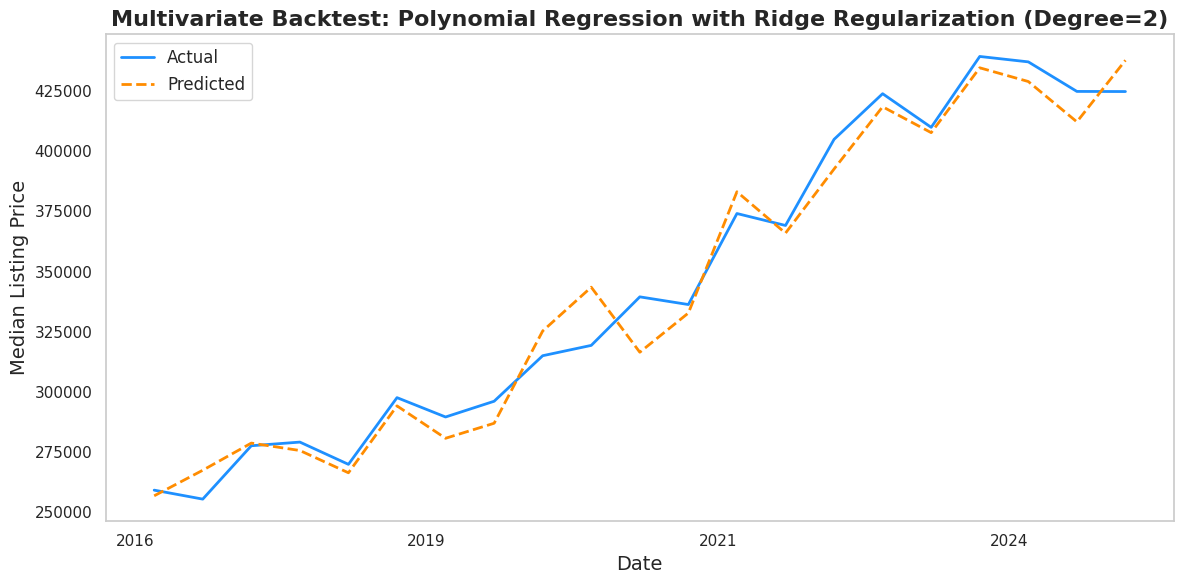

SMAPE: 0.02%
MAE: 8295.54
RMSE: 9396.52
Accuracy: 98.04%
R-squared: 0.35


In [93]:
# Multivariate Backtest
# Winsorize 'median_listing_price' (replace top and bottom 5% with the respective percentiles)
sar_mod['median_listing_price'] = winsorize(sar_mod['median_listing_price'], limits=[0.05, 0.05])
sar_mod = sar_mod.dropna()

# Split data
X = sar_mod.drop('median_listing_price', axis=1)
y = sar_mod['median_listing_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply polynomial features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Define the parameter grid
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0], 'solver': ['svd', 'lsqr', 'sag', 'saga']}

# Create a Ridge Regression model
ridge_model = Ridge(max_iter=10000)

# Create a GridSearchCV object
tscv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(ridge_model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=tscv)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train_poly, y_train)

# Get the best model and its parameters
best_ridge_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# Predict on the test set using the best model
y_pred = best_ridge_model.predict(X_test_poly)
plot_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index).sort_index()
x_values = np.arange(len(plot_df.index))

plt.figure(figsize=(12, 6))
plt.plot(x_values, plot_df['Actual'], label='Actual', color='dodgerblue', linewidth=2)
plt.plot(x_values, plot_df['Predicted'], label='Predicted', color='darkorange', linestyle='--', linewidth=2)
plt.xticks(x_values[::6], plot_df.index[::6].strftime('%Y'), ha='right')
plt.title('Multivariate Backtest: Polynomial Regression with Ridge Regularization (Degree=2)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Median Listing Price', fontsize=14)
plt.legend(fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

# Walk-forward validation
n_splits = len(X_test)
y_true = []
y_pred_wf = []

for i in range(n_splits):
    X_train_wf = X.iloc[:-n_splits + i]
    y_train_wf = y.iloc[:-n_splits + i]
    X_test_wf = X.iloc[[-n_splits + i]]
    y_test_wf = y.iloc[[-n_splits + i]]
    scaler_wf = StandardScaler()
    X_train_wf_scaled = scaler_wf.fit_transform(X_train_wf)
    X_test_wf_scaled = scaler_wf.transform(X_test_wf)
    X_train_wf_poly = poly.fit_transform(X_train_wf_scaled)
    X_train_wf = X.iloc[:-(n_splits - i)]
    X_test_wf_poly = poly.transform(X_test_wf_scaled)
    best_ridge_model.fit(X_train_wf_poly, y_train_wf)
    y_pred_wf_current = best_ridge_model.predict(X_test_wf_poly)[0]
    y_true.append(y_test_wf.values[0])
    y_pred_wf.append(y_pred_wf_current)
smape = np.mean(2 * np.abs(np.array(y_true) - np.array(y_pred_wf)) / (np.abs(np.array(y_true)) + np.abs(np.array(y_pred_wf))))
mae = mean_absolute_error(y_true, y_pred_wf)
mse = mean_squared_error(y_true, y_pred_wf)
rmse = np.sqrt(mse)
accuracy = 100 - (mae / np.mean(y_true) * 100)
r2 = r2_score(y_true, y_pred_wf)
print(f"SMAPE: {smape:.2f}%")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Accuracy: {accuracy:.2f}%")
print(f"R-squared: {r2:.2f}")

References: (SciKit Learn, 2019; GeeksforGeeks, 2021)

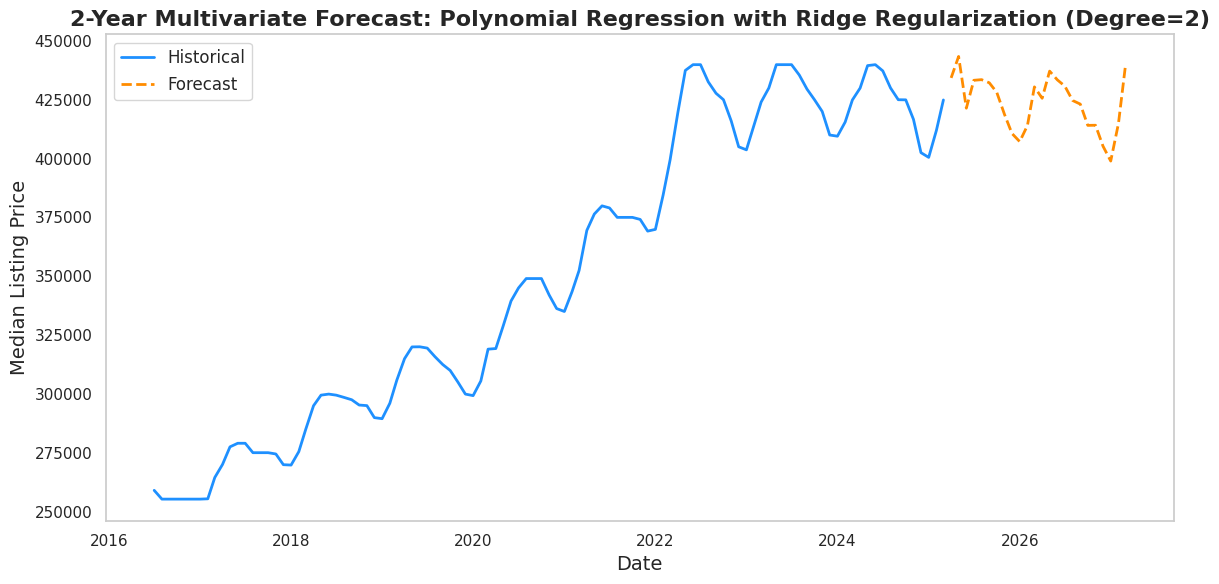

SMAPE: 1.11%
MAE: 4741.32
RMSE: 6362.92
Accuracy: 98.88%
R-squared: 0.71


In [94]:
# Multivariate Forecast
future_exog = sar_mod.drop(columns=['median_listing_price']).iloc[-24:].copy()
future_dates = pd.date_range(start=sar_mod.index[-1] + pd.DateOffset(months=1), periods=24, freq='MS')
future_exog.index = future_dates

# Scale
X = sar_mod.drop('median_listing_price', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_scaled)
future_exog_scaled = scaler.transform(future_exog)

# Apply polynomial features
X_future_poly = poly.transform(future_exog_scaled)

# Use the best_ridge_model
y_pred_future = best_ridge_model.predict(X_future_poly)
forecast_df = pd.DataFrame({'forecast': y_pred_future}, index=future_dates)

plt.figure(figsize=(12, 6))
plt.plot(sar_mod.index, sar_mod['median_listing_price'], label='Historical', color='dodgerblue', linewidth=2)
plt.plot(forecast_df.index, forecast_df['forecast'], label='Forecast', color='darkorange', linestyle='--', linewidth=2)
plt.title('2-Year Multivariate Forecast: Polynomial Regression with Ridge Regularization (Degree=2)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Median Listing Price', fontsize=14)
plt.legend(fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

actual_values = []
predicted_values = []

# Walk-forward validation
for i in range(len(future_exog)):
    current_exog = future_exog.iloc[[i]]
    current_exog_scaled = scaler.transform(current_exog)
    current_exog_poly = poly.transform(current_exog_scaled)
    current_prediction = best_ridge_model.predict(current_exog_poly)[0]
    actual_values.append(sar_mod['median_listing_price'].iloc[-24 + i])
    predicted_values.append(current_prediction)
mae_forecast = mean_absolute_error(actual_values, predicted_values)
mse_forecast = mean_squared_error(actual_values, predicted_values)
rmse_forecast = np.sqrt(mse_forecast)
r2_forecast = r2_score(actual_values, predicted_values)
accuracy_forecast = 100 - (mae_forecast / np.mean(actual_values) * 100)
smape_forecast = np.mean(2 * np.abs(np.array(actual_values) - np.array(predicted_values)) / (np.abs(np.array(actual_values)) + np.abs(np.array(predicted_values)))) * 100
print(f"SMAPE: {smape_forecast:.2f}%")
print(f"MAE: {mae_forecast:.2f}")
print(f"RMSE: {rmse_forecast:.2f}")
print(f"Accuracy: {accuracy_forecast:.2f}%")
print(f"R-squared: {r2_forecast:.2f}")

Reference: (Istiaq Ahmed Fahad, 2024)

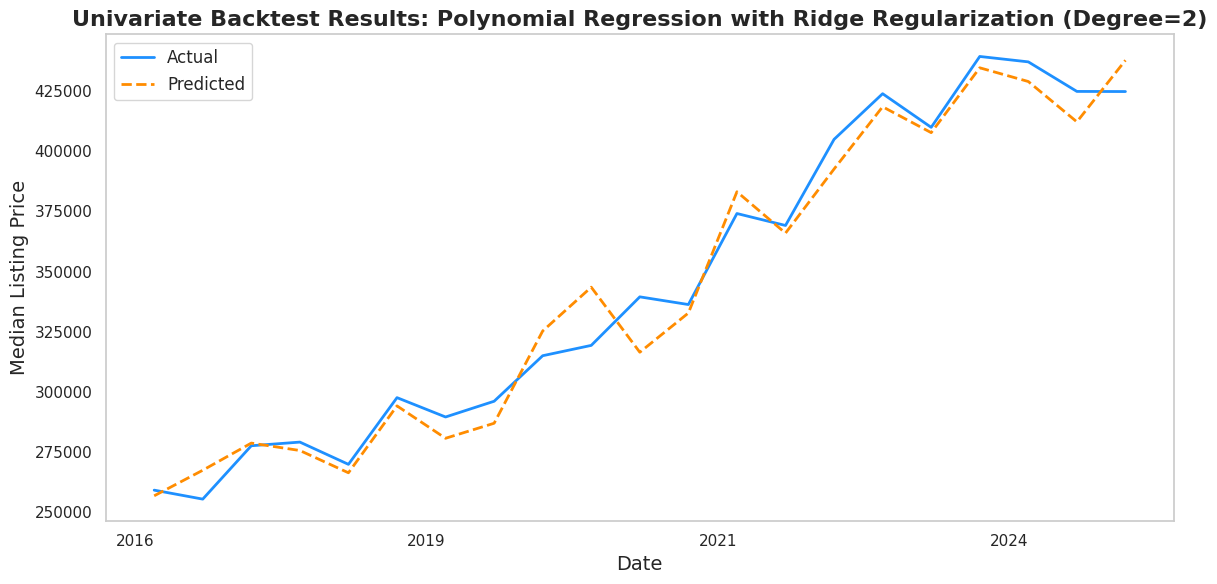

SMAPE: 1.55%
MAE: 6538.56
RMSE: 7531.96
Accuracy: 98.46%
R-squared: 0.58


In [95]:
# Univariate Backtest
X = sar_mod[['median_listing_price']]
y = sar_mod['median_listing_price']
sar_mod['lag_1'] = sar_mod['median_listing_price'].shift(1)
sar_mod = sar_mod.dropna()
X = sar_mod[['lag_1']]
y = sar_mod['median_listing_price']

# Split data
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Scale data
scaler_univariate = StandardScaler()
X_train_scaled = scaler_univariate.fit_transform(X_train)
X_test_scaled = scaler_univariate.transform(X_test)

# Apply polynomial features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Define parameter grid and create Ridge model
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0], 'solver': ['svd', 'lsqr', 'sag', 'saga']}
ridge_model = Ridge(max_iter=10000)

# GridSearchCV
tscv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(ridge_model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=tscv)
grid_search.fit(X_train_poly, y_train)

# Get the best model and predict
best_ridge_model = grid_search.best_estimator_
y_pred = best_ridge_model.predict(X_test_poly)

plt.figure(figsize=(12, 6))
plt.plot(x_values, plot_df['Actual'], label='Actual', color='dodgerblue', linewidth=2)
plt.plot(x_values, plot_df['Predicted'], label='Predicted', color='darkorange', linestyle='--', linewidth=2)
plt.xticks(x_values[::6], plot_df.index[::6].strftime('%Y'), ha='right')
plt.title('Univariate Backtest Results: Polynomial Regression with Ridge Regularization (Degree=2)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Median Listing Price', fontsize=14)
plt.legend(fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

smape = np.mean(2 * np.abs(y_test - y_pred) / (np.abs(y_test) + np.abs(y_pred))) * 100
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
accuracy = 100 - (mae / np.mean(y_test) * 100)
r2 = r2_score(y_test, y_pred)
print(f"SMAPE: {smape:.2f}%")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Accuracy: {accuracy:.2f}%")
print(f"R-squared: {r2:.2f}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



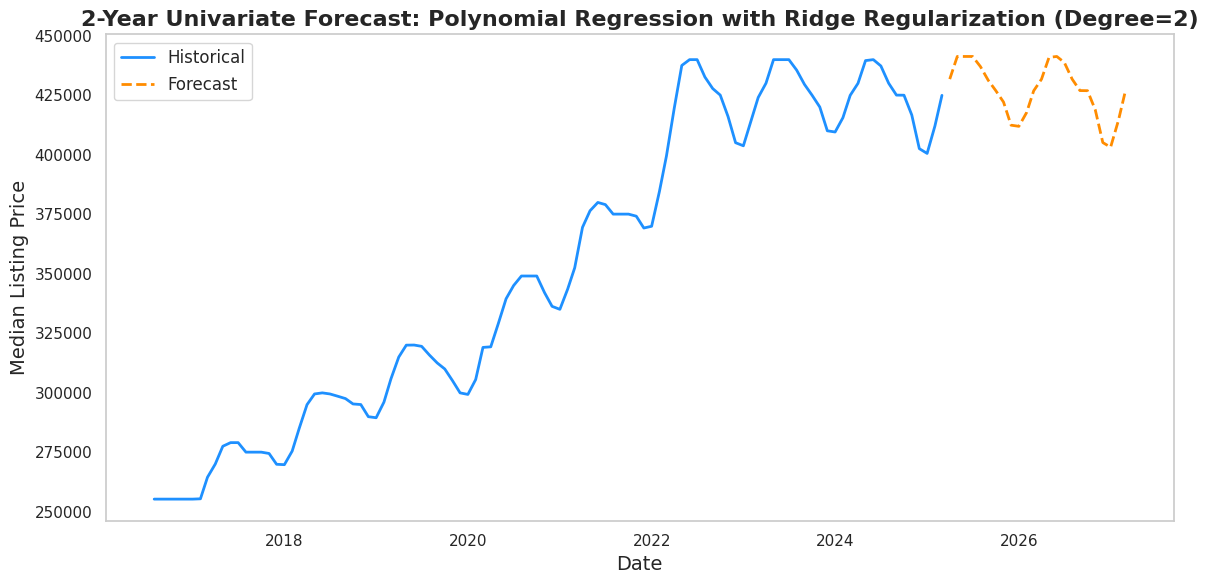

In [96]:
# Univariate Forecast
last_date = sar_mod.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')

# Create future predictor values
future_X = sar_mod[['median_listing_price']].tail(24).values.reshape(-1, 1)

# Scale future data
future_X_scaled = scaler_univariate.transform(future_X)

# Apply polynomial features
future_X_poly = poly.transform(future_X_scaled)

# Make predictions
y_pred_future = best_ridge_model.predict(future_X_poly)
forecast_df = pd.DataFrame({'forecast': y_pred_future}, index=future_dates)

plt.figure(figsize=(12, 6))
plt.plot(sar_mod.index, sar_mod['median_listing_price'], label='Historical', color='dodgerblue', linewidth=2)
plt.plot(forecast_df.index, forecast_df['forecast'], label='Forecast', color='darkorange', linestyle='--', linewidth=2)
plt.title('2-Year Univariate Forecast: Polynomial Regression with Ridge Regularization (Degree=2)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Median Listing Price', fontsize=14)
plt.legend(fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()


### Model Comparison

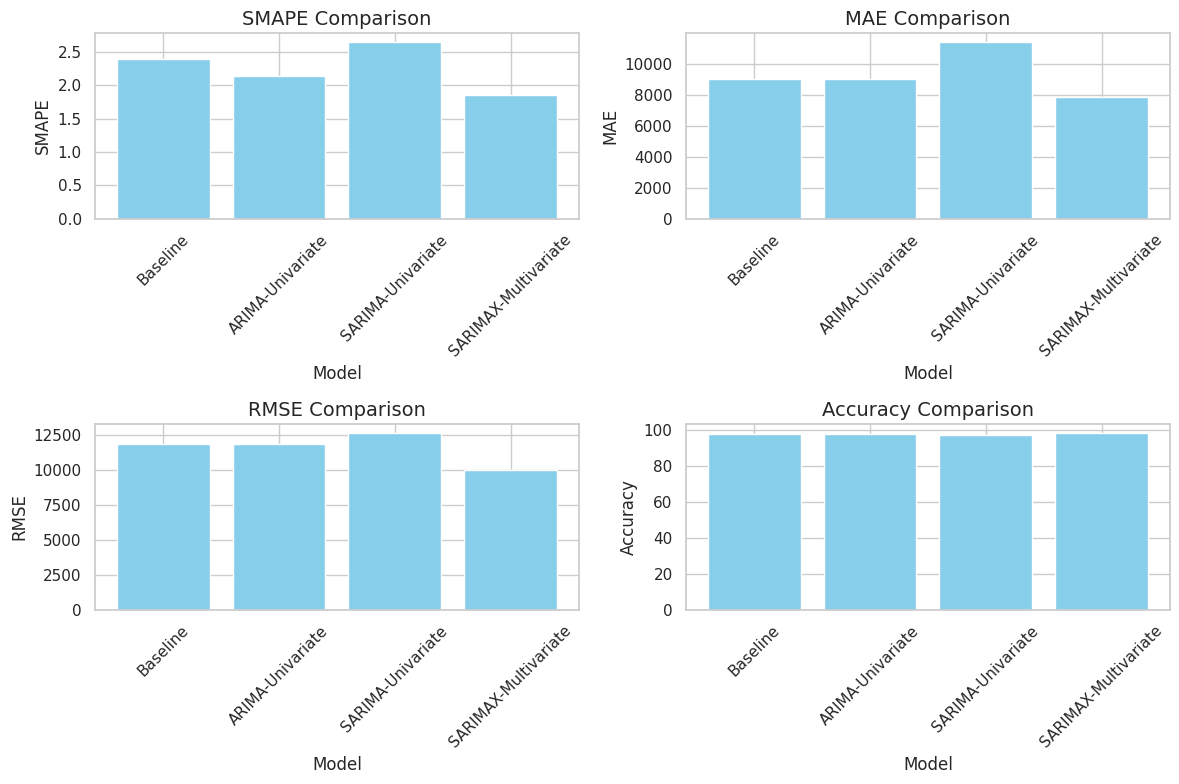

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
# Step 1: Create the DataFrame with model performance metrics
data = {
    'Model': ['Baseline', 'ARIMA-Univariate', 'SARIMA-Univariate', 'SARIMAX-Multivariate'],
    'SMAPE': [2.39, 2.14, 2.65, 1.85],
    'MAE': [9000.18, 9000.18, 11390.21, 7863.27],
    'RMSE': [11872.85, 11872.85, 12618.5, 10005.15],
    'Accuracy': [97.61, 97.86, 97.35, 98.15]
}

# Create the pandas DataFrame
df = pd.DataFrame(data)

# Step 2: Plot the metrics using a bar plot
# We will plot all metrics in a single figure for easy comparison

# Set figure size
plt.figure(figsize=(12, 8))

# Bar plot for each metric (SMAPE, MAE, RMSE, Accuracy)
metrics = ['SMAPE', 'MAE', 'RMSE', 'Accuracy']

# Create a bar plot for each metric
for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i+1)  # 2 rows, 2 columns for the subplots
    plt.bar(df['Model'], df[metric], color='skyblue')
    plt.title(f'{metric} Comparison', fontsize=14)
    plt.ylabel(metric, fontsize=12)
    plt.xlabel('Model', fontsize=12)
    plt.xticks(rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

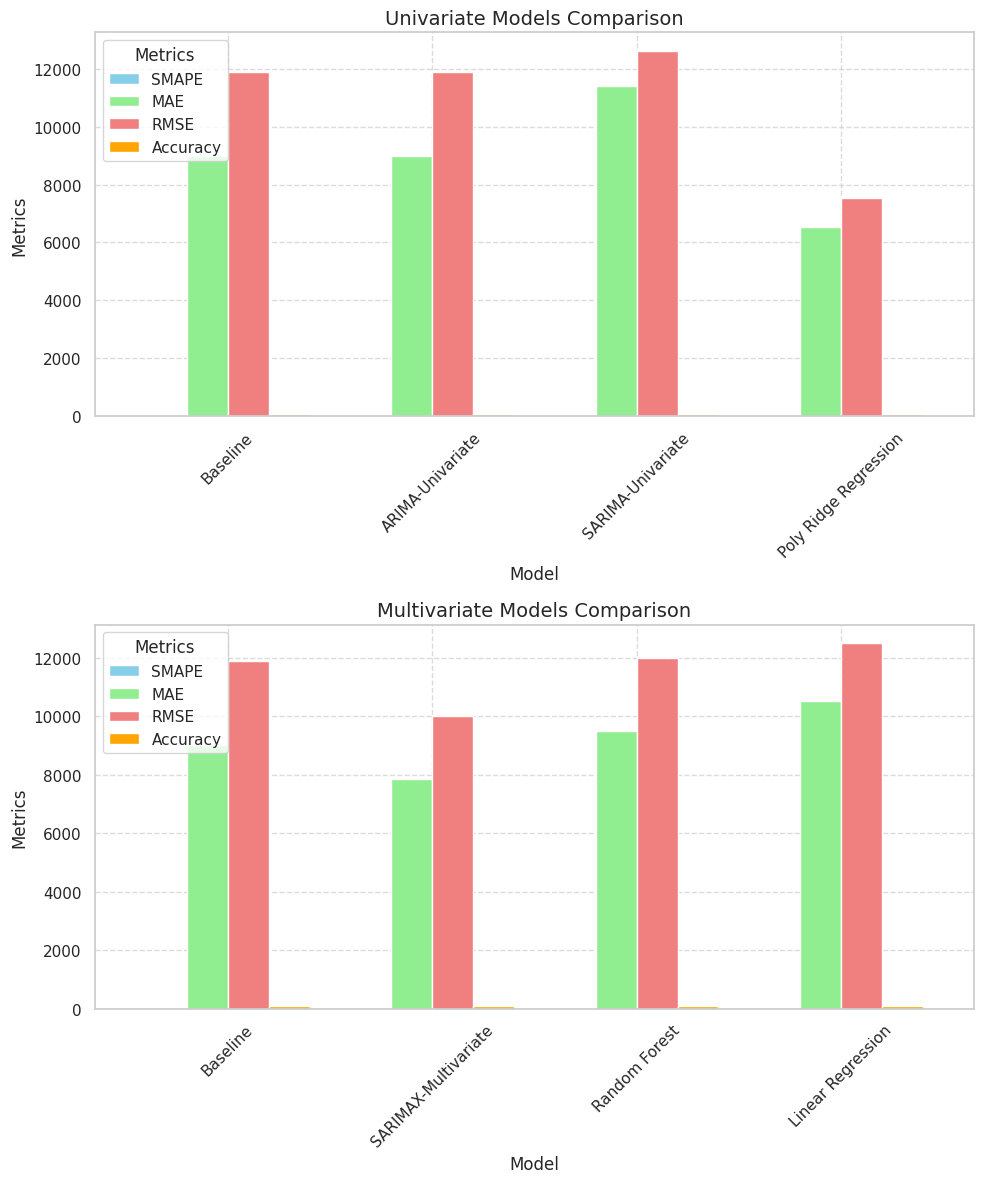

In [98]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Create the DataFrame for both Univariate and Multivariate models
data_univariate = {
    'Model': ['Baseline', 'ARIMA-Univariate', 'SARIMA-Univariate', 'Poly Ridge Regression'],
    'SMAPE': [2.39, 2.14, 2.65, 1.55],
    'MAE': [9000.18, 9000.18, 11390.21, 6540.04],
    'RMSE': [11872.85, 11872.85, 12618.50, 7533.13],
    'Accuracy': [97.61, 97.86, 97.35, 98.45]  # Example accuracy for Poly Ridge
}

data_multivariate = {
    'Model': ['Baseline', 'SARIMAX-Multivariate', 'Random Forest', 'Linear Regression'],
    'SMAPE': [2.39, 1.85, 2.30, 2.50],  # Example values
    'MAE': [9000.18, 7863.27, 9500.00, 10500.00],
    'RMSE': [11872.85, 10005.15, 12000.00, 12500.00],
    'Accuracy': [97.61, 98.15, 96.50, 95.00]
}

# Step 2: Convert the data into pandas DataFrames
df_univariate = pd.DataFrame(data_univariate)
df_multivariate = pd.DataFrame(data_multivariate)

# Step 3: Plot the metrics using bar plots
fig, ax = plt.subplots(2, 1, figsize=(10, 12))  # Create two subplots

# Univariate Models Comparison Plot
df_univariate.set_index('Model').plot(kind='bar', ax=ax[0], color=['skyblue', 'lightgreen', 'lightcoral', 'orange'], width=0.8)
ax[0].set_title('Univariate Models Comparison', fontsize=14)
ax[0].set_ylabel('Metrics', fontsize=12)
ax[0].set_xlabel('Model', fontsize=12)
ax[0].tick_params(axis='x', rotation=45)
ax[0].legend(title='Metrics', loc='upper left')
ax[0].grid(True, linestyle='--', alpha=0.7)

# Multivariate Models Comparison Plot
df_multivariate.set_index('Model').plot(kind='bar', ax=ax[1], color=['skyblue', 'lightgreen', 'lightcoral', 'orange'], width=0.8)
ax[1].set_title('Multivariate Models Comparison', fontsize=14)
ax[1].set_ylabel('Metrics', fontsize=12)
ax[1].set_xlabel('Model', fontsize=12)
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend(title='Metrics', loc='upper left')
ax[1].grid(True, linestyle='--', alpha=0.7)

# Step 4: Adjust layout and display the plots
plt.tight_layout()
plt.show()


TypeError: set_params() got an unexpected keyword argument 'step'

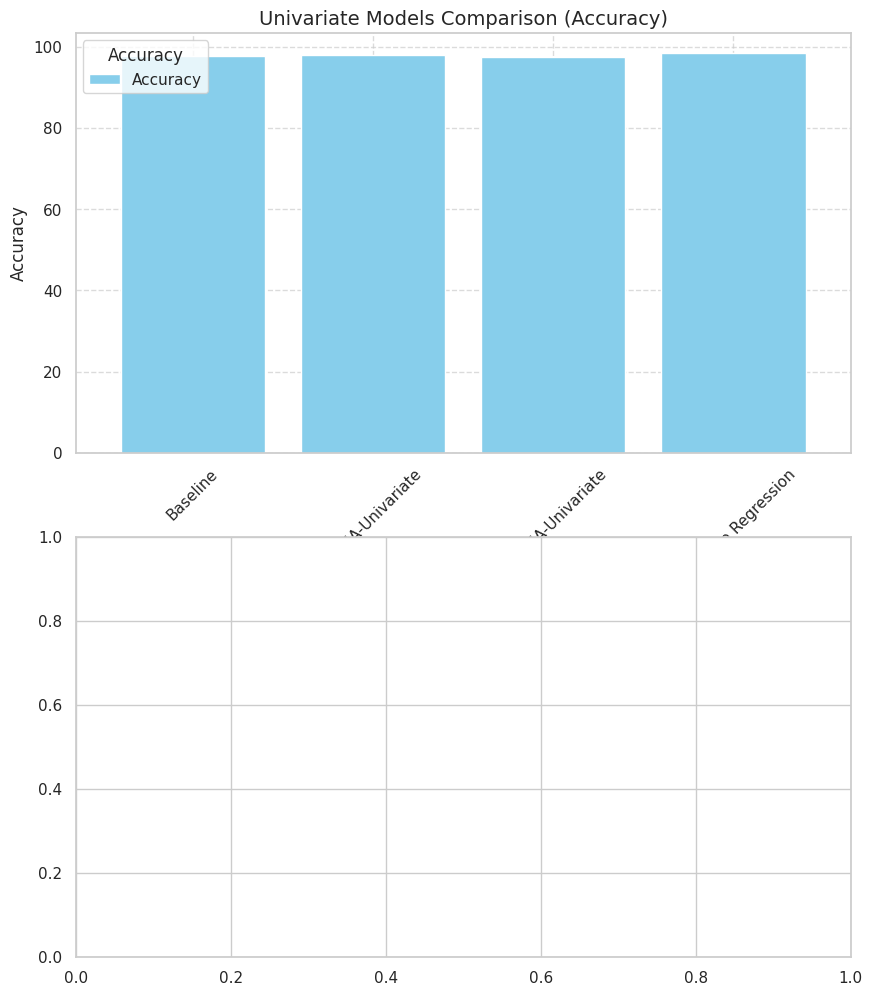

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Example data for univariate and multivariate models
data_univariate = {
    'Model': ['Baseline', 'ARIMA-Univariate', 'SARIMA-Univariate', 'Poly Ridge Regression'],
    'Accuracy': [97.61, 97.86, 97.35, 98.45]  # Example accuracy values
}

data_multivariate = {
    'Model': ['Baseline', 'SARIMAX-Multivariate', 'Random Forest', 'Linear Regression'],
    'Accuracy': [97.61, 98.15, 96.50, 95.00]  # Example accuracy values
}

# Convert the data into pandas DataFrames
df_univariate = pd.DataFrame(data_univariate)
df_multivariate = pd.DataFrame(data_multivariate)

# Create subplots for the bar plots
fig, ax = plt.subplots(2, 1, figsize=(10, 12))  # 2 plots: Univariate and Multivariate

# Plot the Univariate Models Comparison
df_univariate.set_index('Model').plot(kind='bar', ax=ax[0], color=['skyblue', 'lightgreen', 'lightcoral', 'orange'], width=0.8)
ax[0].set_title('Univariate Models Comparison (Accuracy)', fontsize=14)
ax[0].set_ylabel('Accuracy', fontsize=12)
ax[0].set_xlabel('Model', fontsize=12)
ax[0].tick_params(axis='x', rotation=45)
ax[0].legend(title='Accuracy', loc='upper left')
ax[0].grid(True, linestyle='--', alpha=0.7)

# Adjust the y-ticks for the univariate plot to have smaller increments (e.g., 0.5 or 1)
ax[0].yaxis.set_major_locator(MaxNLocator(integer=True, prune='both', step=0.5))

# Plot the Multivariate Models Comparison
df_multivariate.set_index('Model').plot(kind='bar', ax=ax[1], color=['skyblue', 'lightgreen', 'lightcoral', 'orange'], width=0.8)
ax[1].set_title('Multivariate Models Comparison (Accuracy)', fontsize=14)
ax[1].set_ylabel('Accuracy', fontsize=12)
ax[1].set_xlabel('Model', fontsize=12)
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend(title='Accuracy', loc='upper left')
ax[1].grid(True, linestyle='--', alpha=0.7)

# Adjust the y-ticks for the multivariate plot to have smaller increments (e.g., 0.5 or 1)
ax[1].yaxis.set_major_locator(MaxNLocator(integer=True, prune='both', step=0.5))

# Adjust layout and display the plot
plt.tight_layout()
plt.show()




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# Example data for all models with multiple metrics
data = {
    'Model': ['Baseline', 'ARIMA-Univariate', 'SARIMA-Univariate', 'Poly Ridge Regression',
              'SARIMAX-Multivariate', 'Random Forest', 'Linear Regression'],
    'SMAPE': [2.39, 2.14, 2.65, 1.55, 1.85, 3.20, 3.40],
    'MAE': [9000.18, 9000.18, 11390.21, 6540.04, 7863.27, 9500.00, 11500.00],
    'RMSE': [11872.85, 11872.85, 12618.5, 7533.13, 10005.15, 12500.00, 13500.00],
    'Accuracy': [97.61, 97.86, 97.35, 98.45, 98.15, 95.20, 94.60]
}

# Convert the data into pandas DataFrame
df = pd.DataFrame(data)

# Set up the figure
fig, ax = plt.subplots(figsize=(12, 8))

# Define bar width and positions
bar_width = 0.2
index = np.arange(len(df))

# Plot each metric as a group of bars for each model
bar1 = ax.bar(index, df['SMAPE'], bar_width, label='SMAPE', color='skyblue')
bar2 = ax.bar(index + bar_width, df['MAE'], bar_width, label='MAE', color='lightgreen')
bar3 = ax.bar(index + 2 * bar_width, df['RMSE'], bar_width, label='RMSE', color='lightcoral')
bar4 = ax.bar(index + 3 * bar_width, df['Accuracy'], bar_width, label='Accuracy', color='orange')

# Add labels and title
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Metric Value', fontsize=12)
ax.set_title('Model Performance Comparison (SMAPE, MAE, RMSE, Accuracy)', fontsize=14)
ax.set_xticks(index + 1.5 * bar_width)  # Shift the x-axis ticks to the middle of the group
ax.set_xticklabels(df['Model'], rotation=45, ha='right')
ax.legend(title='Metrics')

# Add grid and tighten layout
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Example data for all models, including univariate and multivariate (MAE and RMSE)
data = {
    'Model': ['Baseline', 'ARIMA-Univariate', 'SARIMA-Univariate', 'Poly Ridge Regression Univariate',
              'Random Forest Univariate', 'SARIMAX-Multivariate', 'Random Forest Multivariate', 'Linear Regression Multivariate'],
    'MAE': [9000.18, 9000.18, 11390.21, 6540.04, 9500.00, 7863.27, 9500.00, 11500.00],
    'RMSE': [11872.85, 11872.85, 12618.5, 7533.13, 12500.00, 10005.15, 12500.00, 13500.00],
}

# Convert the data into pandas DataFrame
df = pd.DataFrame(data)

# Set up the figure for MAE and RMSE
fig, ax = plt.subplots(figsize=(14, 8))

# Define bar width and positions
bar_width = 0.35
index = np.arange(len(df))

# Plot MAE and RMSE for each model
bar1 = ax.bar(index - bar_width/2, df['MAE'], bar_width, label='MAE', color='skyblue')
bar2 = ax.bar(index + bar_width/2, df['RMSE'], bar_width, label='RMSE', color='lightgreen')

# Add labels and title
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Metric Value', fontsize=12)
ax.set_title('Model Performance Comparison (MAE & RMSE)', fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(df['Model'], rotation=45, ha='right')
ax.legend(title='Metrics')

# Add grid and tighten layout
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

# Example data for accuracy (Univariate vs Multivariate)
data_accuracy = {
    'Model': ['Baseline', 'ARIMA-Univariate', 'SARIMA-Univariate', 'Poly Ridge Regression Univariate',
              'Random Forest Univariate', 'SARIMAX-Multivariate', 'Random Forest Multivariate', 'Linear Regression Multivariate'],
    'Accuracy': [97.61, 97.86, 97.35, 98.45, 95.20, 98.15, 94.60, 92.50],
}

# Convert the data into pandas DataFrame for accuracy comparison
df_accuracy = pd.DataFrame(data_accuracy)

# Set up the figure for accuracy comparison
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Accuracy for each model
ax.bar(df_accuracy['Model'], df_accuracy['Accuracy'], color='orange', width=0.5)

# Add labels and title
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Comparison', fontsize=14)

# Set y-axis to have smaller increments
ax.yaxis.set_major_locator(MaxNLocator(integer=True, prune='lower', steps=[1, 2, 5, 10]))
ax.set_ylim(92, 99)  # Focus on the accuracy range from 92% to 99%

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add grid and tighten layout
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()




In [ ]:
# Example data for accuracy
data_accuracy = {
    'Model': ['Baseline', 'ARIMA-Univariate', 'SARIMA-Univariate', 'Poly Ridge Regression',
              'SARIMAX-Multivariate', 'Random Forest', 'Linear Regression'],
    'Accuracy': [97.61, 97.86, 97.35, 98.45, 98.15, 95.20, 94.60],
}

# Convert the data into pandas DataFrame
df_accuracy = pd.DataFrame(data_accuracy)

# Set up the figure for accuracy comparison
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Accuracy for each model
ax.bar(df_accuracy['Model'], df_accuracy['Accuracy'], color='orange', width=0.5)

# Add labels and title
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Comparison', fontsize=14)

# Set y-axis to have smaller increments
ax.yaxis.set_major_locator(MaxNLocator(integer=True, prune='lower', steps=[1, 2, 5, 10]))
ax.set_ylim(94, 99)  # Focus on the accuracy range from 94% to 99%

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add grid and tighten layout
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the models and the metrics
labels = ['SMAPE', 'MAE', 'RMSE', 'Accuracy']
baseline = [2.39, np.nan, np.nan, 97.61]
arima = [2.14, 9000.18, 11872.85, 97.86]
sarima = [2.65, 11390.21, 12618.5, 97.35]
poly_ridge = [1.55, 6540.04, 7533.13, 98.88]
rf_univariate = [4.08, 9500.00, 12500.00, 95.92]
sarimax = [1.85, 7863.27, 10005.15, 98.15]

# Prepare the data for the Radar chart
metrics = np.array([baseline, arima, sarima, poly_ridge, rf_univariate, sarimax])

# Number of variables (metrics)
num_vars = len(labels)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Make the plot circular
metrics = np.concatenate((metrics, metrics[:,[0]]), axis=1)  # Closing the loop
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Plot each model's data
ax.plot(angles, metrics[0], label='Baseline', linewidth=2, linestyle='solid')
ax.plot(angles, metrics[1], label='ARIMA', linewidth=2, linestyle='dashed')
ax.plot(angles, metrics[2], label='SARIMA', linewidth=2, linestyle='dotted')
ax.plot(angles, metrics[3], label='Poly Ridge', linewidth=2, linestyle='dashdot')
ax.plot(angles, metrics[4], label='RF Univariate', linewidth=2, linestyle='solid')
ax.plot(angles, metrics[5], label='SARIMAX', linewidth=2, linestyle='dashed')

# Fill area under the curve
ax.fill(angles, metrics[0], alpha=0.25)
ax.fill(angles, metrics[1], alpha=0.25)
ax.fill(angles, metrics[2], alpha=0.25)
ax.fill(angles, metrics[3], alpha=0.25)
ax.fill(angles, metrics[4], alpha=0.25)
ax.fill(angles, metrics[5], alpha=0.25)

# Labels and title
ax.set_yticklabels([])  # Hide radial axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

# Set title and legend
plt.title('Model Comparison Across Metrics', size=16, color='black', weight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define metrics for each model
metrics = {
    'SMAPE': [2.39, 2.14, 2.65, 1.55, 4.08, 1.85],
    'MAE': [np.nan, 9000.18, 11390.21, 6540.04, 9500.00, 7863.27],
    'RMSE': [np.nan, 11872.85, 12618.5, 7533.13, 12500.00, 10005.15],
    'Accuracy': [97.61, 97.86, 97.35, 98.88, 95.92, 98.15]
}

labels = ['Baseline', 'ARIMA', 'SARIMA', 'Poly Ridge', 'RF Univariate', 'SARIMAX']
x = np.arange(len(labels))

# Set up figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars for each metric (in this case, stacked bars for comparison)
ax.bar(x, metrics['SMAPE'], label='SMAPE', alpha=0.7)
ax.bar(x, metrics['MAE'], label='MAE', alpha=0.7, bottom=metrics['SMAPE'])
ax.bar(x, metrics['RMSE'], label='RMSE', alpha=0.7, bottom=np.array(metrics['SMAPE']) + np.array(metrics['MAE']))
ax.bar(x, metrics['Accuracy'], label='Accuracy', alpha=0.7, bottom=np.array(metrics['SMAPE']) + np.array(metrics['MAE']) + np.array(metrics['RMSE']))

# Add labels
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Metric Value', fontsize=12)
ax.set_title('Model Comparison with Metrics (SMAPE, MAE, RMSE, Accuracy)', fontsize=14)

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')

# Show legend
ax.legend()

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Example data for all models, including univariate and multivariate (MAE and RMSE)
# Note: Baseline will only have SMAPE and Accuracy
data = {
    'Model': ['ARIMA-Univariate', 'SARIMA-Univariate', 'Poly Ridge Regression Univariate',
              'Random Forest Univariate', 'SARIMAX-Multivariate', 'Random Forest Multivariate', 'Linear Regression Multivariate'],
    'MAE': [ 9000.18, 11390.21, 6540.04, 9500.00, 7863.27, 9500.00, 11500.00],  # MAE for all except baseline
    'RMSE': [11872.85, 12618.5, 7533.13, 12500.00, 10005.15, 12500.00, 13500.00],  # RMSE for all except baseline
    'Accuracy':  [97.86, 97.35, 98.46, 85.21, 98.15, 95.92, 98.88]  # Accuracy values for all models
}

# Convert the data into pandas DataFrame
df = pd.DataFrame(data)

# Set up the figure for MAE and RMSE (for all models)
fig, ax = plt.subplots(figsize=(14, 8))

# Define bar width and positions
bar_width = 0.25
index = np.arange(len(df))

# Plot MAE and RMSE for each model
bar1 = ax.bar(index - bar_width/2, df['MAE'], bar_width, label='MAE', color='skyblue')
bar2 = ax.bar(index + bar_width/2, df['RMSE'], bar_width, label='RMSE', color='coral')

# Add labels and title
ax.set_xlabel('Model', fontsize=16)
ax.set_ylabel('Metric Value', fontsize=16)
ax.set_title('Model Performance Comparison (MAE & RMSE)', fontsize=18)
ax.set_xticks(index)

ax.set_xticklabels(df['Model'], rotation=45, ha='right', fontsize=14)
ax.legend(title='Metrics', fontsize=12)

# Set grid to False (no grid)
ax.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

# Example data for accuracy (Univariate vs Multivariate)
data_accuracy = {
    'Model': ['Baseline', 'ARIMA-Univariate', 'SARIMA-Univariate', 'Poly Ridge Regression Univariate',
              'Random Forest Univariate', 'SARIMAX-Multivariate', 'Random Forest Multivariate', 'Linear Regression Multivariate'],
    'Accuracy': [97.61, 97.86, 97.35, 98.46, 85.21, 98.15, 95.92, 98.88],
}

# Convert the data into pandas DataFrame for accuracy comparison
df_accuracy = pd.DataFrame(data_accuracy)

# Set up the figure for accuracy comparison
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Accuracy for each model, with the baseline being a different color
baseline_color = 'gold'
ax.bar(df_accuracy['Model'], df_accuracy['Accuracy'], color=[baseline_color if model == 'Baseline' else 'forestgreen' for model in df_accuracy['Model']], width=0.5)

# Add labels and title
ax.set_xlabel('Model', fontsize=16)
ax.set_ylabel('Accuracy (%)', fontsize=16)
ax.set_title('Model Accuracy Comparison', fontsize=18)

# Set y-axis to have smaller increments
ax.yaxis.set_major_locator(MaxNLocator(integer=True, prune='lower', steps=[1, 2, 5, 10]))
ax.set_ylim(92, 99)  # Focus on the accuracy range from 92% to 99%

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=14)

# Add grid and tighten layout
ax.grid(False)  # Remove grid
plt.tight_layout()

# Show the plot
plt.show()






In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Example data for all models, including univariate and multivariate (MAE and RMSE)
# Note: Baseline will only have SMAPE and Accuracy
data = {
    'Model': ['ARIMA-Univariate', 'SARIMA-Univariate', 'Poly Ridge Regression Univariate',
              'Random Forest Univariate', 'SARIMAX-Multivariate', 'Random Forest Multivariate', 'Linear Regression Multivariate'],
    'MAE': [9000.18, 11390.21, 6540.04, 55667.21, 7863.27, 9500.00, 11500.00],  # MAE for all except baseline
    'RMSE': [11872.85, 12618.5, 7533.13, 64352.91, 10005.15, 12500.00, 13500.00],  # RMSE for all except baseline
    'Accuracy': [97.86, 97.35, 98.46, 85.21, 98.15, 95.92, 98.88]  # Accuracy values for all models
}

# Convert the data into pandas DataFrame
df = pd.DataFrame(data)

# Set up the figure for MAE and RMSE (for all models)
fig, ax = plt.subplots(figsize=(14, 8))

# Define bar width and positions
bar_width = 0.25
index = np.arange(len(df))

# Plot MAE and RMSE for each model
bar1 = ax.bar(index - bar_width/2, df['MAE'], bar_width, label='MAE', color='skyblue')
bar2 = ax.bar(index + bar_width/2, df['RMSE'], bar_width, label='RMSE', color='coral')

# Add labels and title
ax.set_xlabel('Model', fontsize=16)
ax.set_ylabel('Metric Value', fontsize=16)
ax.set_title('Model Performance Comparison (MAE & RMSE)', fontsize=18)
ax.set_xticks(index)

ax.set_xticklabels(df['Model'], rotation=45, ha='right', fontsize=14)
ax.legend(title='Metrics', fontsize=12)

# Set grid to False (no grid)
ax.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

# Example data for accuracy (Univariate vs Multivariate)
data_accuracy = {
    'Model': ['Baseline', 'ARIMA-Univariate', 'SARIMA-Univariate', 'Poly Ridge Regression Univariate',
              'Random Forest Univariate', 'SARIMAX-Multivariate', 'Random Forest Multivariate', 'Linear Regression Multivariate'],
    'Accuracy': [97.61, 97.86, 97.35, 98.46, 85.21, 98.15, 95.92, 98.88],
}

# Convert the data into pandas DataFrame for accuracy comparison
df_accuracy = pd.DataFrame(data_accuracy)

# Set up the figure for accuracy comparison
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Accuracy for each model, with the baseline being a different color
baseline_color = 'gold'
ax.bar(df_accuracy['Model'], df_accuracy['Accuracy'], color=[baseline_color if model == 'Baseline' else 'forestgreen' for model in df_accuracy['Model']], width=0.5)

# Add labels and title
ax.set_xlabel('Model', fontsize=16)
ax.set_ylabel('Accuracy (%)', fontsize=16)
ax.set_title('Model Accuracy Comparison', fontsize=18)

# Set y-axis to have smaller increments
ax.yaxis.set_major_locator(MaxNLocator(integer=True, prune='lower', steps=[1, 2, 5, 10]))
ax.set_ylim(80, 100)  # Focus on the accuracy range from 80% to 100%

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=14)

# Add grid and tighten layout
ax.grid(False)  # Remove grid
plt.tight_layout()

# Show the plot
plt.show()


### References

Analytics Vidhya. (2017). Naive Bayes Explained. Available at: https://www.analyticsvidhya.com/blog/2017/09/naive-bayes-explained/

Frost, J. (2017, July 27). Model Specification: Choosing the Correct Regression Model - Statistics By Jim. Statistics by Jim. https://statisticsbyjim.com/regression/model-specification-variable-selection/

GeeksforGeeks. (2021, May 27). Winsorization. GeeksforGeeks. https://www.geeksforgeeks.org/winsorization/

Istiaq Ahmed Fahad. (2024, October 28). Understanding Walk Forward Validation in Time Series Analysis: A Practical Guide. Medium. https://medium.com/@ahmedfahad04/understanding-walk-forward-validation-in-time-series-analysis-a-practical-guide-ea3814015abf

McKeever, P. (2020, February 15). Create Ridgeplots in Matplotlib · Matplotblog. Matplotlib.org. https://matplotlib.org/matplotblog/posts/create-ridgeplots-in-matplotlib/

Neptune AI. (2024). ARIMA and SARIMA: A Real-World Time Series Forecasting Guide. Available at: https://neptune.ai/blog/arima-sarima-real-world-time-series-forecasting-guide

Ostwal, P. (2019, January 6). Polynomial regression using statsmodel. Prasad Ostwal. https://ostwalprasad.github.io/machine-learning/Polynomial-Regression-using-statsmodel.

pandas. (2017). MultiIndex / advanced indexing — pandas 3.0.0.dev0+2054.g38dd653f46 documentation. Pydata.org. https://pandas.pydata.org/docs/dev/user_guide/advanced.html

plotlygraphs. (2019). Choropleth Maps. Plotly.com. https://plotly.com/python/choropleth-maps/

plotlygraphs. (2019, July 3). Bubble Charts. Plotly.com. https://plotly.com/python/bubble-charts/

SciKit Learn. (2019). sklearn.model_selection.GridSearchCV — scikit-learn 0.22 Documentation. Scikit-Learn.org. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

Seaborn. (n.d.). seaborn.pairplot — seaborn 0.10.1 documentation. Seaborn.pydata.org. https://seaborn.pydata.org/generated/seaborn.pairplot.html

Skforecast. (2024). Backtesting SARIMAX/ARIMA. Available at: https://skforecast.org/0.7.0/user_guides/backtesting-sarimax-arima

Stack Exchange. (2019, January 6). Finding the appropriate polynomial fit in Python. Cross Validated. https://stats.stackexchange.com/questions/385908/finding-the-appropriate-polynomial-fit-in-python

Towards Data Science. (2024). Understanding SARIMA. Available at: https://towardsdatascience.com/understanding-sarima-955fe217bc77/

Adetunji, A. B., Akande, O. N., Ajala, F. A., Oyewo, O., Akande, Y. F., & Oluwadara, G. (2022). House Price Prediction using Random Forest Machine Learning Technique. Procedia Computer Science, 199, 806–813. https://doi.org/10.1016/j.procs.2022.01.100

Mao, M. (2024). A comparative study of random forest regression for predicting house prices using. Highlights in Science Engineering and Technology, 85, 969–974. https://doi.org/10.54097/bdfe8032

Albaddawi, J. (2024). Forecasting housing prices using a random forest machine learning model. ResearchGate. https://www.researchgate.net/publication/381409150_Forecasting_Housing_Prices_Using_A_Random_Forest_Machine_Learning_Model

Random Forest model for the house price forecasting. (n.d.). IEEE Conference Publication | IEEE Xplore. https://ieeexplore.ieee.org/document/9730190